In [1]:
#!/usr/bin/env python3
"""
Inspect all metadata + data inside a UVH5 file.

Usage:
    python inspect_uvh5.py /path/to/file.uvh5
"""

from pathlib import Path
import sys
import numpy as np
from pyuvdata import UVData

# --------------------------------------------------------------------
# Helper: pretty-print array-like content safely
# --------------------------------------------------------------------
def summarize_array(name, arr, units=None, max_items=8):
    print(f"\n--- {name} ---")
    print("  type :", type(arr))
    print("  shape:", arr.shape)
    print("  dtype:", arr.dtype)
    if units is not None:
        print("  units:", units)

    # Guard against fully empty arrays
    flat = np.asarray(arr).ravel()
    if flat.size == 0:
        print("  [empty array]")
        return

    # NaN / Inf stats
    if np.issubdtype(arr.dtype, np.number) or np.iscomplexobj(arr):
        nan_count = np.isnan(flat).sum()
        inf_count = np.isinf(flat).sum()
        print("  NaNs:", nan_count, "  Infs:", inf_count)
        try:
            print("  Min :", np.nanmin(flat))
            print("  Max :", np.nanmax(flat))
        except ValueError:
            # e.g. all NaNs
            print("  Min/Max: could not compute (maybe all NaNs?)")

    # Show a few entries
    n = flat.size
    sample = flat[:max_items]
    print(f"  sample ({min(max_items, n)} of {n}):", sample, "..." if n > max_items else "")


# --------------------------------------------------------------------
# Physical descriptions for known keys (both public & private)
# --------------------------------------------------------------------
DESCRIPTIONS = {
    "data_array": "Complex visibilities V(ant1, ant2, time, freq, pol). Units: Jy.",
    "_data_array": "Complex visibilities V(ant1, ant2, time, freq, pol). Units: Jy.",
    "flag_array": "Boolean flags (True = flagged/unusable visibility sample).",
    "_flag_array": "Boolean flags (True = flagged/unusable visibility sample).",
    "nsample_array": "Number of samples averaged into each visibility.",
    "_nsample_array": "Number of samples averaged into each visibility.",
    "uvw_array": "Baseline vectors in meters (u,v,w) in ITRF coordinates.",
    "_uvw_array": "Baseline vectors in meters (u,v,w) in ITRF coordinates.",
    "freq_array": "Frequency channels in Hz.",
    "_freq_array": "Frequency channels in Hz.",
    "time_array": "Time of each visibility (Julian Date).",
    "_time_array": "Time of each visibility (Julian Date).",
    "lst_array": "Local Sidereal Time (radians) for each visibility.",
    "_lst_array": "Local Sidereal Time (radians) for each visibility.",
    "antenna_positions": "XYZ positions of antennas in meters (ITRF).",
    "_antenna_positions": "XYZ positions of antennas in meters (ITRF).",
    "ant_1_array": "First antenna index for each baseline-time (blt).",
    "_ant_1_array": "First antenna index for each baseline-time (blt).",
    "ant_2_array": "Second antenna index for each baseline-time (blt).",
    "_ant_2_array": "Second antenna index for each baseline-time (blt).",
    "baseline_array": "Integer code 256*ant1 + ant2 for each blt.",
    "_baseline_array": "Integer code 256*ant1 + ant2 for each blt.",
    "_Ntimes": "Number of unique times in the data.",
    "_Nbls": "Number of unique baselines.",
    "_Nblts": "Number of baseline-time samples.",
    "_Nfreqs": "Number of frequency channels.",
    "_Npols": "Number of polarization states.",
    "_spw_array": "Spectral window indices.",
    "_flex_spw_id_array": "Flex spectral window ID per frequency channel.",
    "_flex_spw_polarization_array": "Flex SPW polarization mapping.",
    "_phase_center_catalog": "Dictionary of phase centers (for multi-phase-center data).",
    "_history": "History string describing how this dataset was generated.",
    "_telescope": "Telescope metadata, including name & location.",
    "_blt_order": "Order of baseline-time axis ('time', 'baseline', etc.).",
    "_blts_are_rectangular": "Whether the (baseline,time) grid is rectangular.",
    "_time_axis_faster_than_bls": "Whether time or baseline is the fastest axis.",
}


def describe_scalar(name, val):
    print(f"\n--- {name} ---")
    print("  type :", type(val))
    print("  value:", val)


# --------------------------------------------------------------------
# Main inspection function
# --------------------------------------------------------------------
def inspect_uvh5(path: Path):
    print(f"\n====================")
    print(f" Inspecting UVH5: {path}")
    print(f"====================\n")

    uv = UVData()
    # run_check=False so we see the raw file contents (no auto-fixing)
    uv.read_uvh5(path, run_check=False)

    # -------- Basic structure via public properties (if present) --------
    print("===== BASIC SHAPE INFO (PUBLIC PROPERTIES) =====")
    for attr in ["Nants_data", "Nants_telescope", "Nbls", "Nblts",
                 "Nfreqs", "Ntimes", "Npols", "Nspws"]:
        if hasattr(uv, attr):
            print(f"{attr}: {getattr(uv, attr)}")

    if hasattr(uv, "integration_time"):
        print("integration_time (s):", getattr(uv, "integration_time"))

    # Some installs may not have object_name / telescope_name
    for attr in ["object_name", "telescope_name"]:
        if hasattr(uv, attr):
            print(f"{attr}:", getattr(uv, attr))
        else:
            print(f"{attr}: [not present on this UVData version]")

    # -------- Key structured arrays (using public attributes) --------
    print("\n===== KEY DATA ARRAYS (PUBLIC ATTRIBUTES) =====")
    if hasattr(uv, "freq_array"):
        summarize_array("freq_array (Hz)", uv.freq_array)
    if hasattr(uv, "time_array"):
        summarize_array("time_array (JD)", uv.time_array)
    if hasattr(uv, "lst_array"):
        summarize_array("lst_array (rad)", uv.lst_array)
    if hasattr(uv, "uvw_array"):
        summarize_array("uvw_array (m)", uv.uvw_array)
    if hasattr(uv, "data_array"):
        summarize_array("data_array (complex Jy)", uv.data_array)
    if hasattr(uv, "flag_array"):
        summarize_array("flag_array (bool)", uv.flag_array)
    if hasattr(uv, "nsample_array"):
        summarize_array("nsample_array", uv.nsample_array)
    if hasattr(uv, "antenna_positions"):
        summarize_array("antenna_positions (m)", uv.antenna_positions)
    if hasattr(uv, "antenna_numbers"):
        describe_scalar("antenna_numbers", uv.antenna_numbers)
    if hasattr(uv, "antenna_names"):
        describe_scalar("antenna_names", uv.antenna_names)

    # Baselines & pols
    if hasattr(uv, "baseline_array"):
        summarize_array("baseline_array", uv.baseline_array)
    if hasattr(uv, "polarization_array"):
        print("\n--- polarization_array ---")
        print("  raw:", uv.polarization_array)
        code2str = {-5: "xx", -6: "yy", -7: "xy", -8: "yx"}
        human = [code2str.get(int(p), int(p)) for p in uv.polarization_array]
        print("  human-readable:", human)

    # -------- Internal metadata via __dict__ --------
    print("\n===== INTERNAL __dict__ CONTENTS =====")
    print("Keys:", list(uv.__dict__.keys()))
    
    print("bls ", len(uv.get_antpairs()), uv.get_antpairs())

    for key, val in uv.__dict__.items():
        # Skip caches & private ugly stuff unless you really want it
        if key.startswith("_UVData__"):
            continue

        desc = DESCRIPTIONS.get(key, None)
        print("\n================================================")
        print(f"Internal key: {key}")
        if desc:
            print("Description :", desc)

        # Array-like?
        if isinstance(val, np.ndarray):
            summarize_array(key, val)
        # Dict-like?
        elif isinstance(val, dict):
            print("  type: dict")
            print(f"  nkeys: {len(val)}")
            # Print a few keys
            for i, (k2, v2) in enumerate(val.items()):
                if i >= 5:
                    print("  ...")
                    break
                print(f"  {i}) {k2}: type={type(v2)}")
        # Simple scalar/string
        elif isinstance(val, (int, float, str, bool)):
            describe_scalar(key, val)
        else:
            # something more complex (e.g., telescope object)
            print("  type:", type(val))
            # Try a repr but truncate
            rep = repr(val)
            if len(rep) > 200:
                rep = rep[:200] + " ..."
            print("  repr:", rep)

    print("\n===== PHYSICAL SUMMARY (KEY FIELDS) =====")
    for k in sorted(set(DESCRIPTIONS.keys())):
        print(f"{k}: {DESCRIPTIONS[k]}")

    print("\n=== Inspection Complete ===\n")


# --------------------------------------------------------------------
# CLI wrapper
# --------------------------------------------------------------------
# if __name__ == "__main__":
#     if len(sys.argv) != 2:
#         print("Usage: python inspect_uvh5.py file.uvh5")
#         sys.exit(1)

#     path = Path(sys.argv[1])
#     if not path.exists():
#         print(f"ERROR: file not found: {path}")
#         sys.exit(1)

#     inspect_uvh5(path)



# --------------------------------------------------------------
BASE_OUTDIR = Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs")
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred_compress")
# MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred")

# ideal ENU, ideal Airy                               airyred, idealT
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
# real ENU, ideal Airy                                airyred, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
# ideal ENU, diameter Airy var (deltaD ~ <.2m)        airyprb, idealT
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
# real ENU, diameter Airy var (deltaD ~ <.2m)         airyprb, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
# ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)      airytilt, idealT
MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
# real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

# --------------------------------------------------------------
print(BASE_OUTDIR/MODEL_DIR/f"fch0310_chunk00000.uvh5" )

inspect_uvh5(BASE_OUTDIR/MODEL_DIR/f"fch0310_chunk00000.uvh5")

/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs/ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt/fch0310_chunk00000.uvh5

 Inspecting UVH5: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs/ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt/fch0310_chunk00000.uvh5

===== BASIC SHAPE INFO (PUBLIC PROPERTIES) =====
Nants_data: 9
Nants_telescope: 9
Nbls: 45
Nblts: 2700
Nfreqs: 1
Ntimes: 60
Npols: 4
Nspws: 1
integration_time (s): [4.98634783 4.98634783 4.98634783 ... 4.98634783 4.98634783 4.98634783]
object_name: [not present on this UVData version]
telescope_name: [not present on this UVData version]

===== KEY DATA ARRAYS (PUBLIC ATTRIBUTES) =====

--- freq_array (Hz) ---
  type : <class 'numpy.ndarray'>
  shape: (1,)
  dtype: float64
  NaNs: 0   Infs: 0
  Min : 84762573.2421875
  Max : 84762573.2421875
  sample (1

 CHANNELS, CHUNKS  [227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
have pols  {-8, -7, -6, -5}
pairs are  [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 5), (5, 6), (5, 7), (5, 8), (6, 6), (6, 7), (6, 8), (7, 7), (7, 8

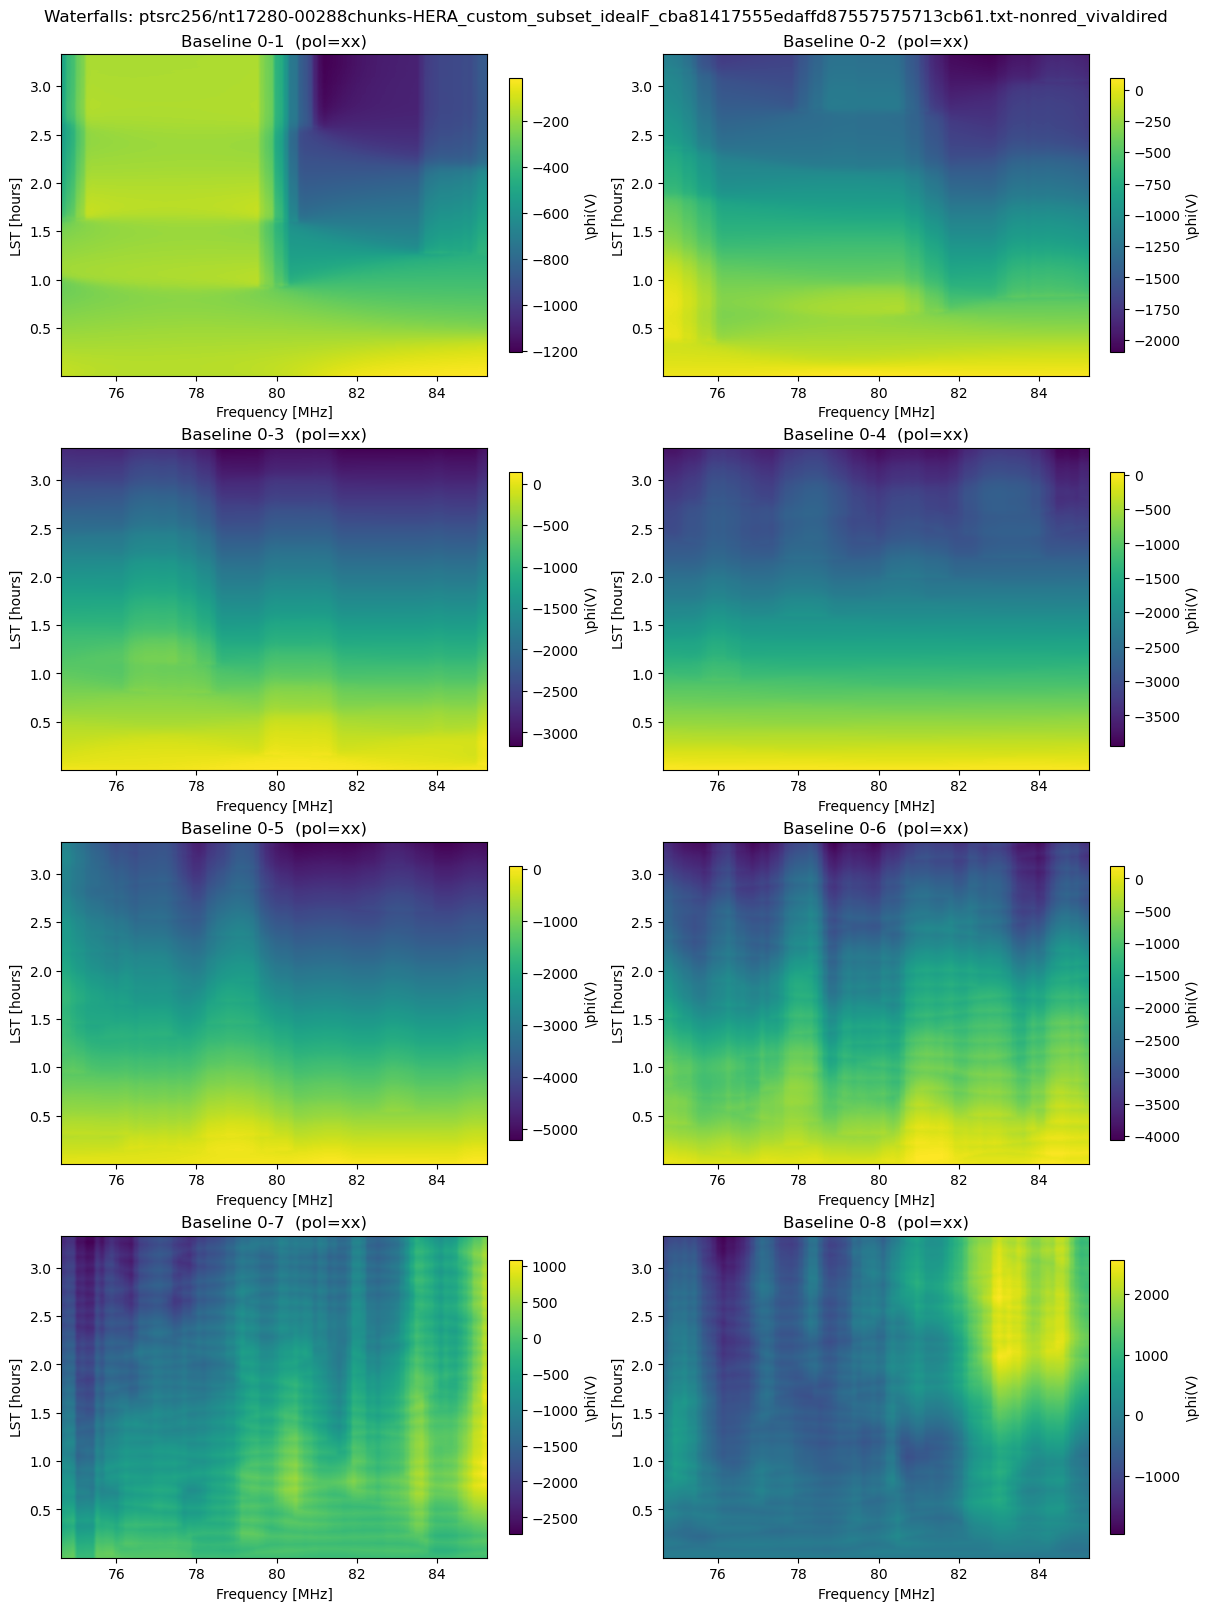

In [7]:
#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVData

# --------------------------------------------------------------
BASE_OUTDIR = Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs")
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred")
# MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred")

# PTSRC
# ideal ENU, ideal Airy                               airyred, idealT
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
# real ENU, ideal Airy                                airyred, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
# ideal ENU, diameter Airy var (deltaD ~ <.2m)        airyprb, idealT
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
# real ENU, diameter Airy var (deltaD ~ <.2m)         airyprb, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
# ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)      airytilt, idealT
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
# real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
# MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

# Vivaldi
# real ENU, ideal Vivaldi                             vivaldired, idealF
MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")

# EOR - GRF
# real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
# MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
# --------------------------------------------------------------

CHANNELS = list(range(227, 315))     # not inclusive
CHUNKS   = list(range(0,40)) #[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   
print(" CHANNELS, CHUNKS ", CHANNELS, CHUNKS) # time chunks
NPLOTS   = 8                         # number of baselines to show
POL_PREFERRED = ["xx", "yy", "xy", "yx"]  

def fname_for(ch, chunk):
    stem = f"fch{ch:04d}_chunk{chunk:05d}"
    return BASE_OUTDIR / MODEL_DIR / f"{stem}.uvh5"
    # return BASE_OUTDIR / MODEL_DIR / f"{stem}_allptsrc_1.uvh5"

def pick_polarization(uv: UVData):
    """Return a polarization integer code that exists in this file, order pref XX/YY/XY/YX."""
    # uv.polarization_array holds integers; map from strings:
    #   'xx'->-5, 'yy'->-6, 'xy'->-7, 'yx'->-8 (pyuvdata convention)
    str2code = {"xx": -5, "xy": -7, "yx": -8, "yy": -6}
    have = set(uv.polarization_array.tolist())
    print("have pols ", have)
    for s in POL_PREFERRED:
        c = str2code[s]
        if c in have:
            return c, s
    # fallback to first available
    c = int(uv.polarization_array[0])
    print("c store is ", c)
    # map back
    code2str = {-5: "xx", -7: "xy", -8: "yx", -6: "yy"}
    return c, code2str.get(c, str(c))

def pick_baselines_full(uvd: UVData, n=4):
    import numpy as np

    pairs = uvd.get_antpairs()
    print("pairs are ", pairs)
    full_pairs = []

    for (a1, a2) in pairs:
        if a1 == a2 or a1 > a2:   # cross corr 
            continue

        # ind = uvd.antpair2ind((a1, a2))
        # # print("ind is ", ind)
        # if isinstance(ind, slice):
        #     ind = np.arange(uvd.Nblts)[ind]     # slice(None,None,step)
        # else:
        #     ind = np.atleast_1d(ind)
        # # print("ind is ", ind)

        # n_samp = ind.size
        # if n_samp == uvd.Ntimes:                 # “full” bls coverage in file
        #     full_pairs.append((a1, a2))
            
        full_pairs.append((a1, a2))

    # if len(full_pairs) < n:
    #     raise RuntimeError(
    #         f"Only {len(full_pairs)} baselines have full Nt={uvd.Ntimes}. "
    #         f"Available: {full_pairs}"
    #     )
        
    print("full_pairs are ", full_pairs)
    return full_pairs[:n]



def read_chunk_channel(uv: UVData, ch, chunk, bl_pairs, pol_code, pol_label):
    """
    Read one file (one frequency channel, one chunk).

    Returns
    -------
    lst_hours_ref : (Nt_common,) ndarray
        LST (hours) for this chunk, taken from the first baseline then trimmed to the
        common length across baselines.
    vis_by_bl : dict[(a1,a2)] -> (Nt_common,) complex ndarray
        Complex visibilities for the chosen polarization, time-sorted per baseline,
        all trimmed to the same Nt_common so stacking later is safe.
    """
    fn = fname_for(ch, chunk)
    if not fn.exists():
        raise FileNotFoundError(f"Missing file: {fn}")

    uvi = UVData()
    uvi.read_uvh5(fn)

    if pol_code not in uvi.polarization_array:
        raise RuntimeError(f"Polarization {pol_code} not present in {fn}")

    # pyuvdata versions
    def get_data_one_pol(a1: int, a2: int):
        try:
            return uvi.get_data((a1, a2), polarizations=pol_code)  # (Nt, 1, 1)
        except TypeError:
            return uvi.get_data((a1, a2, pol_label))               # (Nt, 1) older API

    vis_by_bl = {}
    lst_hours_ref = None
    lengths = []

    for i, (a1, a2) in enumerate(bl_pairs):
        # blt indices for this baseline
        blt_inds_obj = uvi.antpair2ind((a1, a2))
        # print("blt_inds_obj ", blt_inds_obj)
        if isinstance(blt_inds_obj, slice):
            # expansion for slice(None,None,step) etc.
            blt_inds = np.arange(uvi.Nblts, dtype=int)[blt_inds_obj]
        else:
            blt_inds = np.atleast_1d(blt_inds_obj).astype(int)
        # print("blt_inds_obj ", blt_inds_obj)
        # print("stuff ", uvi.time_array[blt_inds_obj]-uvi.time_array[blt_inds])


        # per-baseline time/LST and sort order
        # print("uvi.time_array ", uvi.time_array)
        # print("uvi.lst_array ", uvi.lst_array)
        t_bl  = uvi.time_array[blt_inds_obj]
        lst_bl = (uvi.lst_array[blt_inds_obj] % (2*np.pi)) * (12.0/np.pi)  # rad→hr
        # order = np.argsort(t_bl)

        # data -> (Nt,) then apply order
        d = np.squeeze(get_data_one_pol(a1, a2))
        if d.ndim != 1:
            d = d.reshape(d.shape[0], -1)[:, 0]
        # d = d[order]
        vis_by_bl[(a1, a2)] = d
        lengths.append(d.shape[0])

        # if i == 0:
        #     lst_hours_ref = lst_bl[order]
        lst_hours_ref = lst_bl

    # --- harmonize lengths across baselines (key fix) ---
    # Nt_common = int(min(lengths))
    # if lst_hours_ref.shape[0] != Nt_common:
    #     lst_hours_ref = lst_hours_ref[:Nt_common]
    # for bl in list(vis_by_bl.keys()):
    #     if vis_by_bl[bl].shape[0] != Nt_common:
    #         vis_by_bl[bl] = vis_by_bl[bl][:Nt_common]

    return lst_hours_ref, vis_by_bl


def main():
    # determine baselines and polarization using first file
    probe_file = fname_for(CHANNELS[0], CHUNKS[0])
    if not probe_file.exists():
        raise SystemExit(f"Cannot find probe file {probe_file} — adjust BASE_OUTDIR/MODEL_DIR.")

    uv0 = UVData()
    uv0.read_uvh5(probe_file)
    pol_code, pol_label = pick_polarization(uv0)
    bls = pick_baselines_full(uv0, n=NPLOTS)
    print(f"Using polarization: {pol_label}  (code {pol_code})")
    print(f"Baselines selected (ant1-ant2): {bls}")

    # Probe Nt per chunk using the first channel as reference
    nt_by_ck = {}
    lst_by_chunk = []  # will also be used to assemble the global LST axis
    for ck in CHUNKS:
        lst_ck, _ = read_chunk_channel(uv0, CHANNELS[0], ck, bls, pol_code, pol_label)
        nt_by_ck[ck] = int(lst_ck.size)
        lst_by_chunk.append(lst_ck)

    nch = len(CHANNELS)
    nck = len(CHUNKS)
    ntime_total = sum(nt_by_ck[ck] for ck in CHUNKS)
    print(f"Nt per chunk: {[nt_by_ck[ck] for ck in CHUNKS]} (total {ntime_total}), "
        f"Nchannels: {nch}, Nchunks: {nck}")

    # Initialize containers per baseline
    W = {bl: np.zeros((ntime_total, nch), dtype=np.complex128) for bl in bls}

    freq_mhz = []

    for j, ch in enumerate(CHANNELS):
        t_cursor = 0
        for k, ck in enumerate(CHUNKS):
            lst_k, vis_k = read_chunk_channel(uv0, ch, ck, bls, pol_code, pol_label)
            nt = lst_k.size  # actual length for this (channel, chunk)

            # fill waterfall for each baseline using actual nt
            for bl in bls:
                W[bl][t_cursor:t_cursor+nt, j] = vis_k[bl]

            # capture freq once per channel (from the first chunk)
            if k == 0:
                uvtmp = UVData(); uvtmp.read_uvh5(fname_for(ch, ck))
                # frequencies in Hz; shape can be (Nfreqs,) or (1, Nfreqs)
                farr = np.atleast_1d(uvtmp.freq_array).ravel()
                freq_mhz_ch = float(farr[0]) / 1e6
                if len(freq_mhz) < j + 1:
                    freq_mhz.append(freq_mhz_ch)
                del uvtmp


            t_cursor += nt

    # Build global time (LST) axis by concatenating chunk LSTs
    lst_hours_all = np.concatenate(lst_by_chunk, axis=0)
    print("lst_hours_all ", len(lst_hours_all) )

    # 3) Plot: one panel per baseline (|V|), Time×Frequency
    fig, axes = plt.subplots(4, 2, figsize=(12, 16), constrained_layout=True)
    axes = axes.ravel()

    X = np.array(freq_mhz)                    # frequency axis
    T = lst_hours_all                         # LST hours
    extent = [X.min(), X.max(), T.min(), T.max()]  # for imshow with origin='lower' we’ll flip appropriately

    for ax, bl in zip(axes, bls):
        amp = np.abs(W[bl])   # (ntime_total, nch)
        print("amp shape ", amp.shape)
        phase = np.angle(W[bl], deg=True)
        print("phase shape ", phase.shape)
        # imshow input (Ny, Nx) = (rows, cols) mapping to (Y, X) = (time, freq)
        # 0 : waterfall, 1, V vs LST, 
        plot_type = 0
        if plot_type == 0:
            im = ax.imshow(
                        # amp,
                        np.unwrap(phase, axis=0), 
                        origin="lower", aspect="auto",
                        extent=[X[0], X[-1], T[0], T[-1]],
                        #    vmin=0,        
                        #    vmax=50        
                        )
            a1, a2 = bl
            ax.set_title(f"Baseline {a1}-{a2}  (pol={pol_label})")
            ax.set_xlabel("Frequency [MHz]")
            ax.set_ylabel("LST [hours]")
            cb = fig.colorbar(im, ax=ax, shrink=0.85)
            # cb.set_label("|V|")
            cb.set_label("\phi(V)")
        if plot_type == 1:
            # V vs LST
            # mean_vis = np.mean(W[bl], axis=1)   # average over freq
            print("shape ", W[bl].shape)
            # print("check 1 ", W[bl][:,15])
            im = ax.plot(
                        T,
                        # amp[:,2],   # pick a frequency index to plot
                        np.unwrap(phase[:,2]), 
                        )
            a1, a2 = bl
            ax.set_title(f"Baseline {a1}-{a2}  (pol={pol_label}), Freq={freq_mhz[2]:.3f} MHz")
            ax.set_xlabel("LST [hours]")
            # ax.set_ylabel("|V|")
            ax.set_ylabel("\phi(V)")

        SKYMODEL_DIR = Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256")

        # sky file that matches your channel scheme; for channel 233:
        # sky_path = SKYMODEL_DIR / f"fch{CHANNELS[0]:04d}.skyh5"   # e.g. fch0227.skyh5 if CHANNELS[0]==227

        # exact MHz read from the UVH5 for that channel (first element of freq_mhz)
        # overlay_bright_sources(
        #     list(axes.ravel()),
        #     sky_path,
        #     freq_mhz=freq_mhz[0],   # aligns source selection with the plotted channel frequencies
        #     top_n=5,
        #     color='w',
        #     alpha=0.8
        # )

    # hide extra axes
    for ax in axes[len(bls):]:
        ax.axis("off")

    fig.suptitle(f"Waterfalls: {MODEL_DIR}", fontsize=12)
    plt.show()


if __name__ == "__main__":
    main()


In [4]:
import os
import glob
# Directory path
data_dir = "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs/ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyred/"
# Total files in directory
all_files = glob.glob(os.path.join(data_dir, "*.uvh5"))
print(f"Total files in directory: {len(all_files)}")
# Find all files matching fch*_chunk00000.uvh5 through fch*_chunk00011.uvh5
files_to_delete = []
for chunk_num in range(12):  # 0-11
    pattern = os.path.join(data_dir, f"fch*_chunk{chunk_num:05d}.uvh5")
    files_to_delete.extend(glob.glob(pattern))
print(f"Files to delete (chunks 0-11): {len(files_to_delete)}")
print(f"Files remaining after deletion: {len(all_files) - len(files_to_delete)}")
# Uncomment the lines below to actually delete
for f in files_to_delete:
    os.remove(f)
print("Deletion complete!")

Total files in directory: 3204
Files to delete (chunks 0-11): 1068
Files remaining after deletion: 2136
Deletion complete!


In [2]:
import h5py

f = h5py.File('/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs/eor-grf-256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred/fch0256_chunk00008.uvh5', 'r')    


In [3]:
d = f['Data']['visdata'][()]
print(d.shape, d)

(540, 1, 4) [[[nan+nanj nan+nanj nan+nanj nan+nanj]]

 [[nan+nanj nan+nanj nan+nanj nan+nanj]]

 [[nan+nanj nan+nanj nan+nanj nan+nanj]]

 ...

 [[nan+nanj nan+nanj nan+nanj nan+nanj]]

 [[nan+nanj nan+nanj nan+nanj nan+nanj]]

 [[nan+nanj nan+nanj nan+nanj nan+nanj]]]


./vsim.py runsim  --ants 0~9  --channels 227~257 --sky-model eor-grf-256  --n-time-chunks 288 --do-time-chunks 0~10 --simulator matvis  --beam-map-csv beam_map_10.csv 

In [ ]:
from pyuvdata import UVData
import numpy as np

fn = "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/outputs/eor-grf-256/nt17280-00288chunks-HERA_custom_subset_cba81417555edaffd87557575713cb61.txt-nonred/fch0227_chunk00000.uvh5"

uv = UVData()
uv.read_uvh5(fn, run_check=False)   # disable automatic fix/check for this test
print((uv.data_array.shape))
print("NaNs in data_array:", np.isnan(uv.data_array).sum())
print("NaNs in autos:",
      np.isnan(uv.data_array[uv.ant_1_array == uv.ant_2_array]).sum())


(540, 1, 4)
[[nan+nanj nan+nanj nan+nanj nan+nanj]
 [nan+nanj nan+nanj nan+nanj nan+nanj]
 [nan+nanj nan+nanj nan+nanj nan+nanj]
 ...
 [nan+nanj nan+nanj nan+nanj nan+nanj]
 [nan+nanj nan+nanj nan+nanj nan+nanj]
 [nan+nanj nan+nanj nan+nanj nan+nanj]]
NaNs in data_array: 2160
NaNs in autos: 240


In [ ]:
from pyuvdata import UVData
fn = fname_for(233, 1)
uvd=UVData(); uvd.read_uvh5(fn)
print(uvd.Ntimes, uvd.Nbls, uvd.Nblts)

print(uvd.get_antpairs())
print(uvd.get_baseline_nums())
print( uvd.get_ants() )
print("get_enu_data_ants ", uvd.get_enu_data_ants() )

print(uvd.history)

print(uvd.get_redundancies())

groups, vecs, lengths = uvd.get_redundancies()
# get_redundant_groups(tol=1.0)  # adjust tol
print("info ", len(groups), [len(g) for g in groups[:5]] )

print(" channel_width ", uvd.channel_width / 1e6)
print(" Nfreqs ", uvd.Nfreqs)
print(" integration_time ", uvd.integration_time[0])

a1=0
a2=1
blt_inds_obj = uvd.antpair2ind((a1, a2))
# print("blt_inds_obj ", blt_inds_obj)
if isinstance(blt_inds_obj, slice):
    # expansion for slice(None,None,step) etc.
    blt_inds = np.arange(uvd.Nblts, dtype=int)[blt_inds_obj]
else:
    blt_inds = np.atleast_1d(blt_inds_obj).astype(int)
# print("time1a ", uvd.time_array[blt_inds] )
# print("time1b ", uvd.lst_array[blt_inds] )
print("time2 ", len((uvd.lst_array[blt_inds] )), (uvd.lst_array[blt_inds] ) * (24 / (2 * np.pi)) ) # rad→hr 

freq_arr = []
for ch in range(227, 257):
    fn = fname_for(ch, 1)
    uvd=UVData(); uvd.read_uvh5(fn)
    freq_arr.append(uvd.freq_array[0] / 1e6)
print(freq_arr)


60 9 540
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8)]
[65536 65537 65538 65539 65540 65541 65542 65543 65544]
[0 1 2 3 4 5 6 7 8]
get_enu_data_ants  (array([[-105.03529563, -110.72150481,    0.81120331],
       [ -90.42745642, -110.66571205,    0.81868112],
       [ -75.81961721, -110.60991928,    0.82615894],
       [ -61.21177801, -110.55412652,    0.83363676],
       [ -46.6039388 , -110.49833375,    0.84111458],
       [ -31.99609959, -110.44254098,    0.84859239],
       [ -17.38826039, -110.38674822,    0.85607021],
       [  -2.78042118, -110.33095545,    0.86354803],
       [  11.82741802, -110.27516269,    0.87102585]]), array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32))
Object created by new_uvdata() at 2025-11-09 20:10:57.459 using pyuvdata version 3.2.0.Visibility Simulation performed with hera_sim's MatVis simulator
Class Repr: <hera_sim.visibilities.matvis.MatVis object at 0x7f9f9d4ab9a0>
hera_sim version: 4.3.3.dev8+ga9f274bcfSimulator Version: 

[74.6307373046875, 74.7528076171875, 74.8748779296875, 74.9969482421875, 75.1190185546875, 75.2410888671875, 75.3631591796875, 75.4852294921875, 75.6072998046875, 75.7293701171875, 75.8514404296875, 75.9735107421875, 76.0955810546875, 76.2176513671875, 76.3397216796875, 76.4617919921875, 76.5838623046875, 76.7059326171875, 76.8280029296875, 76.9500732421875, 77.0721435546875, 77.1942138671875, 77.3162841796875, 77.4383544921875, 77.5604248046875, 77.6824951171875, 77.8045654296875, 77.9266357421875, 78.0487060546875, 78.1707763671875]


In [15]:
from pyuvdata import UVData
import numpy as np

u = UVData(); u.read_uvh5(fn)
pairs = u.get_antpairs()
print("pairs in file:", pairs)

for bl in pairs:
    ind = u.antpair2ind(bl)
    if isinstance(ind, slice):
        ind = np.arange(u.Nblts)[ind]   # handles slice(None, None, step) cleanly
    else:
        ind = np.atleast_1d(ind)
    print(f"{bl}: {ind.size} samples")


pairs in file: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8)]
(0, 0): 60 samples
(0, 1): 60 samples
(0, 2): 60 samples
(0, 3): 60 samples
(0, 4): 60 samples
(0, 5): 60 samples
(0, 6): 60 samples
(0, 7): 60 samples
(0, 8): 60 samples


In [ ]:
# #!/usr/bin/env python3
# """
# Read .skyh5 files (pyradiosky SkyModel) and plot a HEALPix map for a given frequency.

# Usage:
#   python plot_skyh5.py /path/to/*.skyh5 --freq-mhz 75.36 --nside 256

# If the file is 'point' components, it bins sources into an NSIDE grid.
# If the file is 'healpix' components, it plots the embedded map.
# """

# from pathlib import Path
# import argparse
# import numpy as np
# import healpy as hp
# import matplotlib.pyplot as plt
# from pyradiosky import SkyModel

# def load_skymodel(path: Path) -> SkyModel:
#     sky = SkyModel()
#     sky.read_skyh5(str(path))
#     return sky

# def nearest_freq_index(sky: SkyModel, freq_hz: float) -> int:
#     # Many ptsrc catalogs are single-frequency (len=1); this is still fine.
#     fa = np.atleast_1d(sky.freq_array).astype(float)
#     return int(np.argmin(np.abs(fa - freq_hz)))

# def bin_point_sources_to_healpix(ra_rad, dec_rad, flux_jy, nside: int, to_surface_brightness=True):
#     """Bin point sources (RA/Dec, Jy) to a HEALPix map at NSIDE."""
#     npix = hp.nside2npix(nside)
#     # HEALPix uses theta=colatitude, phi=longitude
#     theta = np.pi/2 - dec_rad
#     phi   = ra_rad % (2*np.pi)
#     pix   = hp.ang2pix(nside, theta, phi)

#     # Sum Jy per pixel
#     jy_per_pix = np.bincount(pix, weights=np.asarray(flux_jy, float), minlength=npix)

#     if to_surface_brightness:
#         # Convert to Jy/sr using pixel area
#         pix_area_sr = 4*np.pi / npix
#         return jy_per_pix / pix_area_sr, "Jy/sr"
#     else:
#         return jy_per_pix, "Jy/pix"

# def plot_one_skyh5(path: Path, freq_mhz: float, nside: int):
#     sky = load_skymodel(path)
#     target_hz = freq_mhz * 1e6

#     if sky.component_type == "healpix":
#         # sky.hpx_inds: None means full-sky map; sky.hpx_map shape ~ (Nfreq, Npix, Npol)
#         fidx = nearest_freq_index(sky, target_hz)
#         # Take Stokes I (pol index 0)
#         M = np.asarray(sky.hpx_map)[fidx, :, 0]
#         units = getattr(sky, "data_unit", "arbitrary")
#         title = f"{path.name} @ {freq_mhz:.2f} MHz (healpix: Stokes I)"
#         hp.mollview(M, unit=units, title=title, norm="hist")
#         plt.show()
#         return

#     # Otherwise: point (component) catalog
#     fidx = nearest_freq_index(sky, target_hz)

#     # Stokes I array can be (Nfreq, Nsrc, Npol) or (Nsrc, Npol) for single-freq files.
#     st = np.asarray(sky.stokes)
#     if st.ndim == 3:
#         I_jy = st[fidx, :, 0]
#     elif st.ndim == 2:
#         I_jy = st[:, 0]
#     else:
#         raise ValueError(f"Unexpected stokes shape {st.shape}")

#     ra = np.asarray(sky.ra)    # radians
#     dec = np.asarray(sky.dec)  # radians

#     # If spectral indices are present and there are multiple freqs, pyradiosky will
#     # already have stokes evaluated per freq; the nearest index above is sufficient.
#     M, units = bin_point_sources_to_healpix(ra, dec, I_jy, nside=nside, to_surface_brightness=True)

#     title = f"{path.name} @ {freq_mhz:.2f} MHz (binned point sources, NSIDE={nside})"
#     hp.mollview(M, unit=units, title=title, norm="hist")
#     plt.show()

# def main():
#     ap = argparse.ArgumentParser()
#     ap.add_argument("files", nargs="+", help="One or more .skyh5 files (glob works if shell expands it).")
#     ap.add_argument("--freq-mhz", type=float, default=None,
#                     help="Frequency (MHz) to plot. If omitted, uses the file's nearest/only frequency.")
#     ap.add_argument("--nside", type=int, default=256, help="NSIDE for point-source binning.")
#     args = ap.parse_args()

#     for f in args.files:
#         p = Path(f)
#         # If user didn’t pass a frequency, peek the file to get its only/first freq
#         if args.freq_mhz is None:
#             sky = load_skymodel(p)
#             fa = np.atleast_1d(sky.freq_array).astype(float)
#             freq_mhz = fa[0] / 1e6
#         else:
#             freq_mhz = float(args.freq_mhz)

#         plot_one_skyh5(p, freq_mhz, args.nside)

# if __name__ == "__main__":
#     main()


Map viewing section.

sky.freq_array  [74630737.3046875] Hz
fa_hz  [74630737.3046875]
File: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/eor-grf-256/fch0227.skyh5
Component type: healpix
Plotting frequency ≈ 74.631 MHz (index 0)
sky type  healpix
stokes shape  (4, 1, 786432)
healpix


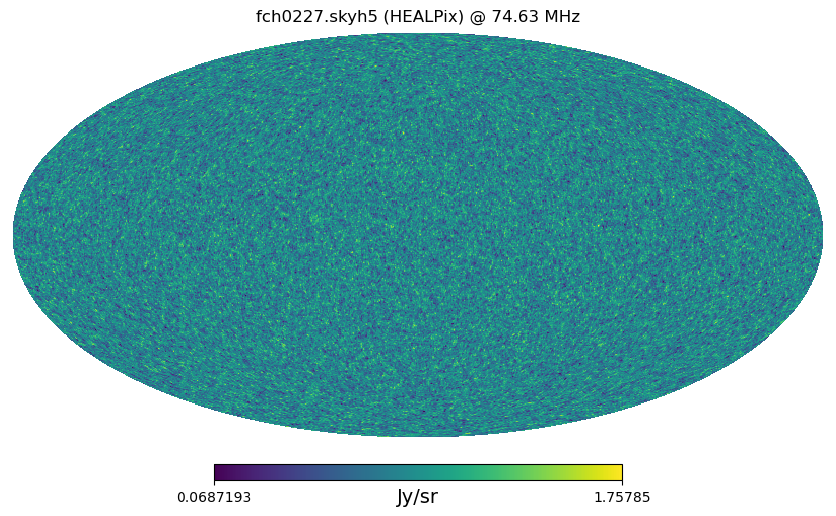

In [1]:
from pathlib import Path
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from pyradiosky import SkyModel
from astropy import units as au   # <-- use 'au' instead of 'u'

def _get_I_jy_at_freq(sky: SkyModel, fidx: int) -> np.ndarray:
    st = sky.stokes
    print("st type ", type(st))
    shp = st.shape
    print("st shape ", shp)
    nfreq = sky.freq_array.size
    print("nfreq ", nfreq)
    nsrc  = sky.Ncomponents
    print("nsrc ", nsrc)

    ax_freq = next(i for i,s in enumerate(shp) if s == nfreq)
    ax_src = next(i for i,s in enumerate(shp) if s == nsrc)
    ax_stokes = next(i for i,s in enumerate(shp) if s in (1, 4))
    print("ax_freq ", ax_freq)
    print("ax_src ", ax_src)
    print("ax_stokes ", ax_stokes)

    arr = np.take(st, fidx, axis=ax_freq)
    print("arr 1 ", arr.shape, arr)
    arr = np.take(arr, 0, axis=ax_stokes)   # Stokes I
    print("arr 2 ", arr.shape, arr)
    arr = np.squeeze(arr)
    print("arr 3 ", arr.shape, arr)

    if arr.ndim != 1 or arr.size != nsrc:
        arr = arr.reshape(-1)
        if arr.size != nsrc:
            raise ValueError(f"After indexing, got {arr.size} fluxes but {nsrc} sources expected.")

    return arr.to_value(au.Jy)  # 'au'

def q_to_numpy(x, unit=None):
    try:
        if hasattr(x, "unit"):
            return np.asarray(x.to_value(unit) if unit is not None else x.value)
        else:
            return np.asarray(x)
    except Exception:
        return np.asarray(x)

def nearest_freq_index(freq_array_hz, target_hz):
    freq_array_hz = np.atleast_1d(freq_array_hz).astype(float)
    return int(np.argmin(np.abs(freq_array_hz - float(target_hz))))

def bin_point_sources_to_healpix(ra_rad, dec_rad, flux_jy, nside=256):
    npix = hp.nside2npix(nside)
    theta = np.pi/2 - dec_rad
    phi = ra_rad % (2*np.pi)
    pix = hp.ang2pix(nside, theta, phi)
    print("pix ", pix)
    m = np.isfinite(flux_jy) & np.isfinite(theta) & np.isfinite(phi) & (flux_jy != 0)
    jy_per_pix  = np.bincount(pix[m], weights=np.asarray(flux_jy, float)[m], minlength=npix)
    print("jy_per_pix ", np.sort(jy_per_pix)[::-1] )
    print("jy_per_pix / (4*np.pi / npix) ", np.sort(jy_per_pix / (4*np.pi / npix))[::-1]  )
    return jy_per_pix #/ (4*np.pi / npix)   # Jy/sr

def plot_skyh5(path, freq_mhz=None, nside=256):
    sky = SkyModel(); sky.read_skyh5(str(path))
    print("sky.freq_array ", sky.freq_array)
    fa_hz = q_to_numpy(sky.freq_array, "Hz").ravel()
    print("fa_hz ", fa_hz)
    f_hz  = float(fa_hz[0]) if freq_mhz is None else float(freq_mhz)*1e6
    fidx  = nearest_freq_index(fa_hz, f_hz)

    print(f"File: {path}")
    print(f"Component type: {sky.component_type}")
    print(f"Plotting frequency ≈ {fa_hz[fidx]/1e6:.3f} MHz (index {fidx})")

    if sky.component_type == "healpix":
        print("sky type ", sky.component_type)
        # stokes: (Nstokes, Nfreqs, Npix)
        st = sky.stokes  # Jy/sr
        print("stokes shape ", st.shape)
        # Stokes I is index 0 in stokes axis
        M_jysr = st[0, 0, :].to_value(au.Jy / au.sr)   # shape (npix,)

        # M_jysr = q_to_numpy(sky.hpx_map, "Jy/sr")[fidx, :, 0]
        
        title = f"{path.name} (HEALPix) @ {fa_hz[fidx]/1e6:.2f} MHz"
        print("healpix")
    else:
        ra_rad = sky.ra.to_value(au.rad)     # 'au' 
        dec_rad = sky.dec.to_value(au.rad)
        I_jy = _get_I_jy_at_freq(sky, fidx)
        print("I_jy ", np.sort(I_jy)[::-1])
        M_jysr = bin_point_sources_to_healpix(ra_rad, dec_rad, I_jy, nside=nside)
        print("M_jysr ", np.sort(M_jysr)[::-1])
        title = f"{path.name} (point→HEALPix) @ {sky.freq_array[fidx].to_value(au.MHz):.3f} MHz"
        print("points")

    # hp.mollview(M_jysr, unit="Jy/sr", title=title)
    hp.mollview(
    M_jysr,
    unit="Jy/sr",
    title=title,
    # min=0,           # lower limit of colorbar
    # max=1,         # upper limit of colorbar
    )
    
    plt.show()


plot_skyh5(
    # Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5"),
    # Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227_full.skyh5"),
    Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/eor-grf-256/fch0227.skyh5"),
    # Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/eor/healpix-maps256.h5"),
    freq_mhz=150,  # or None to use the file's first freq
    # nside=256
)


In [2]:
import h5py
import numpy as np

raw = "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/raw/eor-grf-nside256.h5"

nan_total = 0
inf_total = 0
min_val = None
max_val = None

with h5py.File(raw, "r") as f:
    dset = f["healpix_maps"]
    nfreq, npix = dset.shape
    print("healpix_maps shape:", dset.shape)

    for i in range(nfreq):
        row = dset[i, :]                     # only one freq slice in memory
        nan_total += np.count_nonzero(np.isnan(row))
        inf_total += np.count_nonzero(np.isinf(row))

        rmin = np.nanmin(row)
        rmax = np.nanmax(row)
        min_val = rmin if min_val is None else min(min_val, rmin)
        max_val = rmax if max_val is None else max(max_val, rmax)

        if i % 100 == 0:
            print(f"  scanned {i}/{nfreq} freqs…")

print("Total NaNs:", nan_total)
print("Total Infs:", inf_total)
print("Global min/max:", min_val, max_val)


healpix_maps shape: (1536, 786432)
  scanned 0/1536 freqs…


  scanned 100/1536 freqs…
  scanned 200/1536 freqs…
  scanned 300/1536 freqs…
  scanned 400/1536 freqs…
  scanned 500/1536 freqs…
  scanned 600/1536 freqs…
  scanned 700/1536 freqs…
  scanned 800/1536 freqs…
  scanned 900/1536 freqs…
  scanned 1000/1536 freqs…
  scanned 1100/1536 freqs…
  scanned 1200/1536 freqs…
  scanned 1300/1536 freqs…
  scanned 1400/1536 freqs…
  scanned 1500/1536 freqs…
Total NaNs: 0
Total Infs: 0
Global min/max: -33.61884896453039 35.21885294851696


In [1]:
from pyradiosky import SkyModel
import numpy as np
from astropy import units as u

sky = SkyModel()
sky.read_skyh5("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/eor-grf-256/fch0227.skyh5")

m = sky.stokes[0, 0, :]   # Jy/sr map
print("stokes shape:", m.shape)
print("NaNs in stokes:", np.isnan(m).sum())
print("Infs in stokes:", np.isinf(m).sum())
print("Min/max:", np.nanmin(m), np.nanmax(m))


stokes shape: (786432,)
NaNs in stokes: 0
Infs in stokes: 0
Min/max: -0.8399354846958503 Jy / sr 0.9323303817268453 Jy / sr


In [49]:
import numpy as np
from pathlib import Path
from astropy import units as au
import healpy as hp
from pyradiosky import SkyModel
from astropy import units as au

def print_top_brightest_sources(path, freq_mhz=None, top_n=10):
    """
    Print the top-N brightest sky components (sources or HEALPix pixels)
    from a .skyh5 file at a specified frequency.

    Parameters
    ----------
    path : str or Path
        Path to .skyh5 file.
    freq_mhz : float or None
        Frequency to examine (MHz). If None, uses first freq.
    top_n : int
        Number of brightest entries to print.
    """

    sky = SkyModel()
    sky.read_skyh5(str(path))

    # frequency handling
    fa = sky.freq_array.to(au.Hz).value.ravel()
    if freq_mhz is None:
        f_hz = fa[0]
    else:
        f_hz = float(freq_mhz) * 1e6
    fidx = int(np.argmin(np.abs(fa - f_hz)))

    print(f"\n=== Top {top_n} brightest components ===")
    print(f"File          : {path}")
    print(f"Sky type      : {sky.component_type}")
    print(f"Frequency     : {fa[fidx]/1e6:.3f} MHz (index {fidx})\n")

    # -----------------------------------------------------------
    # CASE 1: POINT SOURCES
    # -----------------------------------------------------------
    if sky.component_type == "point":
        # Extract flux at the chosen frequency
        st = sky.stokes  # may have shape (Nfreq, Nsrc, Nstokes) or permuted

        # determine axes
        shp = st.shape
        nfreq = fa.size
        nsrc  = sky.Ncomponents
        ax_freq   = next(i for i,s in enumerate(shp) if s == nfreq)
        ax_src    = next(i for i,s in enumerate(shp) if s == nsrc)
        ax_stokes = next(i for i,s in enumerate(shp) if s in (1, 4))

        # extract I(ν)
        arr = np.take(st, fidx, axis=ax_freq)
        arr = np.take(arr, 0, axis=ax_stokes)   # Stokes-I
        flux_jy = arr.to_value(au.Jy).reshape(nsrc)

        # sort by brightness
        idx = np.argsort(flux_jy)[::-1]  # descending

        print("Top brightest POINT SOURCES (Stokes I in Jy):\n")
        print(f"{'Rank':>4} {'Flux [Jy]':>12} {'RA [deg]':>12} {'Dec [deg]':>12}")

        ra_deg  = sky.ra.to(au.deg).value
        dec_deg = sky.dec.to(au.deg).value

        for rank, src_i in enumerate(idx[:top_n], start=1):
            print(f"{rank:4d} {flux_jy[src_i]:12.4g} {ra_deg[src_i]:12.4f} {dec_deg[src_i]:12.4f}")

        print()
        return

    # -----------------------------------------------------------
    # CASE 2: HEALPIX MAP
    # -----------------------------------------------------------
    if sky.component_type == "healpix":
        # sky.hpx_map shape : (Nfreq, Npix, Npol)
        M = sky.hpx_map.to(au.Jy/au.sr).value
        map_jysr = M[fidx, :, 0]  # Stokes I

        idx = np.argsort(map_jysr)[::-1]

        print("Top brightest HEALPIX PIXELS (intensity in Jy/sr):\n")
        print(f"{'Rank':>4} {'I [Jy/sr]':>12} {'Theta [deg]':>12} {'Phi [deg]':>12}")

        nside = hp.npix2nside(len(map_jysr))

        for rank, pix in enumerate(idx[:top_n], start=1):
            theta, phi = hp.pix2ang(nside, pix)
            print(f"{rank:4d} {map_jysr[pix]:12.4g} {np.degrees(theta):12.4f} {np.degrees(phi)%360:12.4f}")

        print()
        return

    # -----------------------------------------------------------
    # OTHER SKY TYPES (rare)
    # -----------------------------------------------------------
    print("Sky type unsupported for brightness listing.")



print_top_brightest_sources(
    "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5",
    freq_mhz=150,
    top_n=20
)



=== Top 20 brightest components ===
File          : /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5
Sky type      : point
Frequency     : 74.631 MHz (index 0)

Top brightest POINT SOURCES (Stokes I in Jy):

Rank    Flux [Jy]     RA [deg]    Dec [deg]
   1    1.783e+04     350.8667      58.8117
   2    1.709e+04     299.8667      40.7339
   3         2243     201.3667     -43.0192
   4         2010     187.7042      12.3911
   5         1665      83.6333      22.0144
   6         1363      50.6750     -37.2006
   7         1082     252.7833       4.9925
   8         1035      79.9583     -45.7789
   9        721.3     139.5250     -12.0956
  10        154.6     333.5667     -17.0267
  11        33.01     160.4667     -31.9351
  12        32.07     109.2753      32.6799
  13        31.13     220.4882     -69.0938
  14        30.98     196.1874      66.8958
  15        30.49     303.7227     -53.4128
  16        30.23     340.6137 

nsrc  785679
arr  (785679,) [3.00873671e-02 4.35531764e-02 1.82097249e-01 ... 1.70864857e+04
 1.78267835e+04 1.36335429e+03] Jy
flux_jy  (785679,) [3.00873671e-02 4.35531764e-02 1.82097249e-01 ... 1.70864857e+04
 1.78267835e+04 1.36335429e+03]


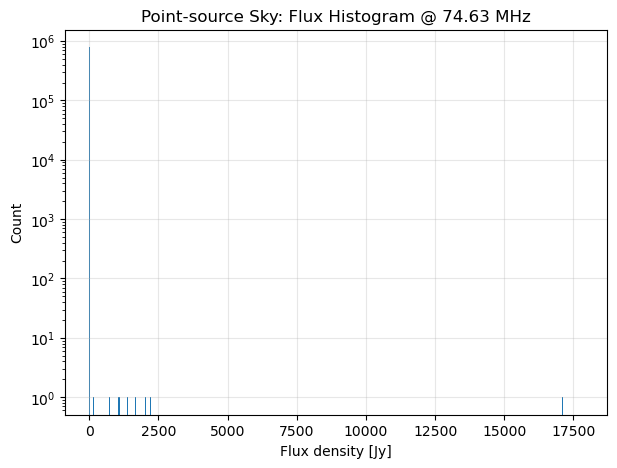

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from pyradiosky import SkyModel
from astropy import units as au


def plot_brightness_histogram(path, freq_mhz=None, nbins=50, log=True):
    """
    Plot histogram of brightness from a .skyh5 file
    - uses flux Jy for point sources
    - uses brightness Jy/sr for HEALPix skies
    """

    sky = SkyModel()
    sky.read_skyh5(str(path))

    # -------------------------
    # Choose frequency
    # -------------------------
    freqs_hz = sky.freq_array.to(au.Hz).value.ravel()

    if freq_mhz is None:
        f_hz = freqs_hz[0]
    else:
        f_hz = float(freq_mhz) * 1e6

    fidx = int(np.argmin(np.abs(freqs_hz - f_hz)))
    nu_mhz = freqs_hz[fidx] / 1e6

    # -------------------------
    # CASE 1: POINT SOURCES
    # -------------------------
    if sky.component_type == "point":
        # Extract Stokes I for this frequency
        st = sky.stokes
        shp = st.shape
        nfreq = freqs_hz.size
        nsrc  = sky.Ncomponents
        print("nsrc ", nsrc)

        ax_freq   = next(i for i,s in enumerate(shp) if s == nfreq)
        ax_src    = next(i for i,s in enumerate(shp) if s == nsrc)
        ax_stokes = next(i for i,s in enumerate(shp) if s in (1,4))

        arr = np.take(st, fidx, axis=ax_freq)
        arr = np.take(arr, 0, axis=ax_stokes)   # I only
        print("arr ", arr.shape, arr)
        flux_jy = arr.to_value(au.Jy).reshape(nsrc)
        print("flux_jy ", flux_jy.shape, flux_jy)

        values = flux_jy
        xlabel = "Flux density [Jy]"
        title  = f"Point-source Sky: Flux Histogram @ {nu_mhz:.2f} MHz"

    # -------------------------
    # CASE 2: HEALPIX MAP
    # -------------------------
    elif sky.component_type == "healpix":
        hpx = sky.hpx_map.to(au.Jy/au.sr).value
        values = hpx[fidx, :, 0]  # (Npix,)
        xlabel = "Brightness [Jy/sr]"
        title  = f"HEALPix Sky: Brightness Histogram @ {nu_mhz:.2f} MHz"

    else:
        raise ValueError("Unsupported sky.component_type")

    # -------------------------
    # Plot histogram
    # -------------------------
    plt.figure(figsize=(7,5))

    if log:
        plt.hist(values[values > 0], bins=nbins, log=True)
    else:
        plt.hist(values, bins=nbins)

    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3)

    plt.show()
    
plot_brightness_histogram(
    "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5",
    freq_mhz=150,
    nbins=500,
    log=True
)



In [ ]:
import numpy as np
from pathlib import Path
from astropy import units as au
from pyradiosky import SkyModel

def _stokes_I_at_freq(sky: SkyModel, fidx: int) -> np.ndarray:
    """Return Stokes I for all components at frequency index fidx, in Jy."""
    st = sky.stokes  # Quantity, shape can vary but includes freq, src, stokes
    shp = st.shape
    nfreq = sky.freq_array.size
    nsrc  = sky.Ncomponents

    # Work out which axis is which
    ax_freq   = next(i for i, s in enumerate(shp) if s == nfreq)
    ax_src    = next(i for i, s in enumerate(shp) if s == nsrc)
    ax_stokes = next(i for i, s in enumerate(shp) if s in (1, 4))

    arr = np.take(st, fidx, axis=ax_freq)   # select frequency
    arr = np.take(arr, 0, axis=ax_stokes)   # Stokes I
    arr = np.squeeze(arr)

    if arr.ndim != 1 or arr.size != nsrc:
        arr = arr.reshape(-1)

    return arr.to_value(au.Jy)  # plain numpy array in Jy

def print_sources_by_name(path, name_list, freq_mhz=None):
    """
    Print RA, Dec, and Stokes I (Jy) for specific named sources in a skyh5 file.

    Parameters
    ----------
    path : str or Path
        Path to .skyh5 file (e.g. ptsrc256/fch0227.skyh5)
    name_list : list of str
        Source names to look for, e.g. ['HydraA', 'PictorA']
    freq_mhz : float or None
        Frequency to evaluate in MHz. If None, uses first available frequency.
    """
    path = Path(path)
    sky = SkyModel()
    sky.read_skyh5(str(path))

    if sky.component_type != "point":
        print(f"File {path.name}: component_type is '{sky.component_type}', not 'point' – no named sources.")
        return

    # frequency selection
    freqs_hz = sky.freq_array.to(au.Hz).value.ravel()
    if freq_mhz is None:
        f_hz = freqs_hz[0]
    else:
        f_hz = float(freq_mhz) * 1e6
    fidx = int(np.argmin(np.abs(freqs_hz - f_hz)))
    nu_mhz = freqs_hz[fidx] / 1e6

    # names array
    names = np.array(sky.name, dtype=str)

    # build mask for all requested names
    name_list = list(name_list)
    mask = np.isin(names, name_list)
    idx = np.where(mask)[0]

    print(f"\nFile         : {path}")
    print(f"component_type : {sky.component_type}")
    print(f"Frequency    : {nu_mhz:.3f} MHz (index {fidx})")
    print(f"Requested    : {name_list}")
    print()

    if idx.size == 0:
        print("No matching source names found in this file.")
        return

    # get fluxes
    flux_jy = _stokes_I_at_freq(sky, fidx)  # shape (Ncomponents,)
    ra_deg  = sky.ra.to(au.deg).value
    dec_deg = sky.dec.to(au.deg).value

    print(f"{'Name':>15} {'Flux [Jy]':>12} {'RA [deg]':>12} {'Dec [deg]':>12}")
    for i in idx:
        print(f"{names[i]:>15} {flux_jy[i]:12.4g} {ra_deg[i]:12.4f} {dec_deg[i]:12.4f}")
    print()

print_sources_by_name(
    "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5",
    name_list=[
        "3C444",
        "CentaurusA",
        "HydraA",
        "PictorA",
        "HerculesA",
        "VirgoA",
        "Crab",
        "CygnusA",
        "CassiopeiaA",
        "FornaxA",
        ],
    freq_mhz=150.0,
)



File         : /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5
component_type : point
Frequency    : 74.631 MHz (index 0)
Requested    : ['3C444', 'CentaurusA', 'HydraA', 'PictorA', 'HerculesA', 'VirgoA', 'Crab', 'CygnusA', 'CassiopeiaA', 'FornaxA']

           Name    Flux [Jy]     RA [deg]    Dec [deg]
          3C444        154.6 Jy     333.5667     -17.0267
     CentaurusA         2243 Jy     201.3667     -43.0192
         HydraA        721.3 Jy     139.5250     -12.0956
        PictorA         1035 Jy      79.9583     -45.7789
      HerculesA         1082 Jy     252.7833       4.9925
         VirgoA         2010 Jy     187.7042      12.3911
           Crab         1665 Jy      83.6333      22.0144
        CygnusA    1.709e+04 Jy     299.8667      40.7339
    CassiopeiaA    1.783e+04 Jy     350.8667      58.8117
        FornaxA         1363 Jy      50.6750     -37.2006



Remove subset ptsrc and rewrite file

In [17]:
import numpy as np
from astropy import units as au
from pyradiosky import SkyModel

def get_flux_jy_at_file_freq(path):
    """Load a point-source skyh5 and return Stokes-I fluxes in Jy (1D array)."""
    sky = SkyModel()
    sky.read_skyh5(str(path))

    if sky.component_type != "point":
        raise ValueError(f"{path} is component_type={sky.component_type}, not 'point'.")

    # freq axis is length sky.freq_array.size (usually 1 for ptsrc files)
    freqs_hz = sky.freq_array.to(au.Hz).value.ravel()
    nfreq = freqs_hz.size
    nsrc  = sky.Ncomponents

    st = sky.stokes  # Quantity with Stokes parameters
    shp = st.shape

    # find axes
    ax_freq   = next(i for i, s in enumerate(shp) if s == nfreq)
    ax_src    = next(i for i, s in enumerate(shp) if s == nsrc)
    ax_stokes = next(i for i, s in enumerate(shp) if s in (1, 4))

    # pick the ONLY frequency in this file (index 0)
    arr = np.take(st, 0, axis=ax_freq)  # (stokes, src) or similar
    arr = np.take(arr, 0, axis=ax_stokes)  # Stokes I
    arr = np.squeeze(arr)

    if arr.ndim != 1 or arr.size != nsrc:
        arr = arr.reshape(-1)

    flux_jy = arr.to_value(au.Jy)  # 1D array of length Ncomponents
    return flux_jy, freqs_hz[0]


In [18]:
import matplotlib.pyplot as plt

def filter_flux_by_percentiles(flux_jy, low_pct=5.0, high_pct=95.0, make_plots=True):
    """
    Given an array of fluxes in Jy, keep only sources with flux between
    low_pct and high_pct percentiles.

    Returns:
        keep_mask  : boolean array, True for sources to keep
        low_thresh : lower flux threshold (Jy)
        high_thresh: upper flux threshold (Jy)
    """

    # mask out non-finite and <=0 values before computing percentiles
    m = np.isfinite(flux_jy) & (flux_jy > 0)
    good = flux_jy[m]

    if good.size == 0:
        raise ValueError("No positive finite flux values found.")

    low_thresh  = np.percentile(good, low_pct)
    high_thresh = np.percentile(good, high_pct)

    keep_mask = (
        np.isfinite(flux_jy) &
        (flux_jy > 0) &
        # (flux_jy >= low_thresh) &
        (flux_jy <= high_thresh)
    )

    print(f"Total sources   : {flux_jy.size}")
    print(f"Finite >0       : {good.size}")
    print(f"Low percentile  : {low_pct:.1f}% -> {low_thresh:.4g} Jy")
    print(f"High percentile : {high_pct:.1f}% -> {high_thresh:.4g} Jy")
    print(f"Kept sources    : {keep_mask.sum()}")

    if make_plots:
        # BEFORE
        plt.figure(figsize=(7,5))
        plt.hist(good, bins=80, log=True)
        plt.axvline(low_thresh,  color="r", linestyle="--", label="low_thresh")
        plt.axvline(high_thresh, color="g", linestyle="--", label="high_thresh")
        plt.xlabel("Flux density [Jy]")
        plt.ylabel("Count")
        plt.title("Flux distribution (all good sources)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # AFTER
        kept_flux = flux_jy[keep_mask]
        plt.figure(figsize=(7,5))
        plt.hist(kept_flux, bins=80, log=True)
        plt.xlabel("Flux density [Jy]")
        plt.ylabel("Count")
        plt.title("Flux distribution (after trimming outliers)")
        plt.grid(alpha=0.3)
        plt.show()

    return keep_mask, low_thresh, high_thresh


File frequency ≈ 74.631 MHz
Total sources   : 785679
Finite >0       : 785679
Low percentile  : 5.0% -> 0.02278 Jy
High percentile : 95.0% -> 0.4531 Jy
Kept sources    : 746395


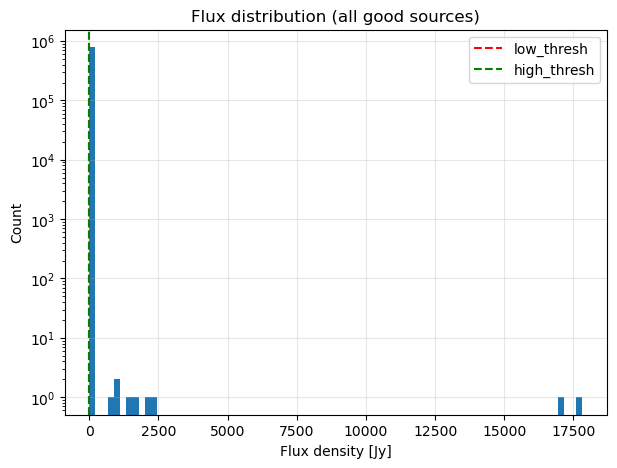

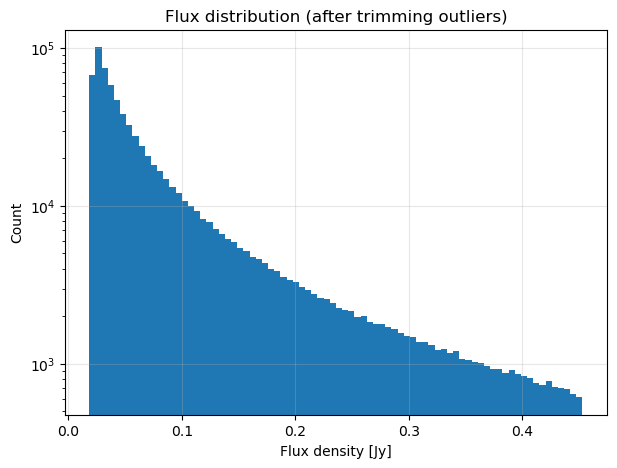

In [20]:
from pathlib import Path

sky_path = Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0227.skyh5")

flux_jy, f_hz = get_flux_jy_at_file_freq(sky_path)
print(f"File frequency ≈ {f_hz/1e6:.3f} MHz")

keep_mask, low_thr, high_thr = filter_flux_by_percentiles(
    flux_jy,
    low_pct=5.0,
    high_pct=95.0,
    make_plots=True
)

# Indices of sources to keep:
keep_indices = np.where(keep_mask)[0]


In [22]:
import numpy as np
from pathlib import Path
from pyradiosky import SkyModel

def write_truncated_sky(path, keep_mask):
    """
    Given a .skyh5 point-source file and a boolean keep_mask over sources,
    rename the original file to <stem>_full.skyh5 and write a truncated
    version (kept sources only) to the original filename.

    Parameters
    ----------
    path : str or Path
        Path to the original .skyh5 file.
    keep_mask : 1D boolean array, length Ncomponents
        True for sources to keep, False for sources to drop.
    """
    path = Path(path)
    sky = SkyModel()
    sky.read_skyh5(str(path))

    if sky.component_type != "point":
        raise ValueError(f"{path} has component_type={sky.component_type}, expected 'point'.")

    nsrc = sky.Ncomponents
    keep_mask = np.asarray(keep_mask, dtype=bool)
    if keep_mask.shape[0] != nsrc:
        raise ValueError(f"keep_mask length {keep_mask.shape[0]} != Ncomponents {nsrc}")

    keep_indices = np.where(keep_mask)[0]
    if keep_indices.size == 0:
        raise ValueError("keep_mask keeps 0 sources; refusing to write empty sky file.")

    # Subselect sources (new SkyModel)
    sky_trunc = sky.select(component_inds=list(keep_indices), inplace=False)

    # Backup original file
    backup_path = path.with_name(path.stem + "_full.skyh5")
    print(f"Renaming original file -> {backup_path}")
    path.rename(backup_path)

    # Write truncated file under original name
    print(f"Writing truncated sky -> {path}")
    sky_trunc.write_skyh5(str(path), clobber=True)

    print(f"Done. Kept {keep_indices.size} / {nsrc} sources.")
    return backup_path, path


In [30]:
backup, newfile = write_truncated_sky(
    "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0318.skyh5",
    keep_mask,
)
print(f"Backup: {backup}, New file: {newfile}")

Renaming original file -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0318_full.skyh5
Writing truncated sky -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0318.skyh5
Done. Kept 746395 / 785679 sources.
Backup: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0318_full.skyh5, New file: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0318.skyh5


In [24]:
for i in range(228, 316):
    print(f"Processing channel {i}...")
    backup, newfile = write_truncated_sky(
        f"/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch{i:04d}.skyh5",
        keep_mask,
    )
    print(f"Backup: {backup}, New file: {newfile}")

Processing channel 228...


Renaming original file -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0228_full.skyh5
Writing truncated sky -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0228.skyh5
Done. Kept 746395 / 785679 sources.
Backup: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0228_full.skyh5, New file: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0228.skyh5
Processing channel 229...
Renaming original file -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0229_full.skyh5
Writing truncated sky -> /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0229.skyh5
Done. Kept 746395 / 785679 sources.
Backup: /lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0229_full.skyh5, New file: /lustre

Test Cells

In [54]:
# ra_dec_to_lst_helper.py
from __future__ import annotations
from pathlib import Path
import numpy as np

# Optional: enable Alt/Az solving if you pass a non-zenith boresight
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from pyradiosky import SkyModel

HERA_LAT_DEG = -30.7215     # HERA/Karoo
HERA_LON_DEG = 21.4283

def read_bright_sources_from_skyh5(
    path: Path | str,
    top_n: int = 10,
    freq_mhz: float | None = None,
) -> np.ndarray:
    """
    Return an array of the top-N brightest point sources at (nearest) frequency.
    columns: ['ra_hr','dec_deg','flux_jy']
    """
    sky = SkyModel()
    sky.read_skyh5(str(path))
    if sky.component_type != "point":
        raise ValueError("This helper expects a point-source SkyModel (.skyh5 with component_type='point').")

    # choose frequency index
    fa = np.atleast_1d(sky.freq_array.to_value(u.Hz)).ravel()
    if freq_mhz is None:
        fidx = 0
    else:
        fidx = int(np.argmin(np.abs(fa - freq_mhz * 1e6)))

    # Stokes-I (index 0 along Stokes axis)
    st = sky.stokes  # Quantity with shape (..., Nstokes)
    # find axes
    shp = st.shape
    ax_freq = next(i for i,s in enumerate(shp) if s == fa.size)
    ax_stok = next(i for i,s in enumerate(shp) if s in (1,4))
    I = np.take(st, fidx, axis=ax_freq)
    I = np.take(I, 0, axis=ax_stok).squeeze().to_value(u.Jy)

    ra_hr   = sky.ra.to_value(u.hourangle)
    dec_deg = sky.dec.to_value(u.deg)

    order = np.argsort(I)[::-1]
    keep  = order[:top_n]
    out = np.zeros((keep.size, 3), dtype=float)
    out[:,0] = ra_hr[keep]
    out[:,1] = dec_deg[keep]
    out[:,2] = I[keep]
    return out  # ra_hr, dec_deg, flux_jy


def transit_window_zenith(
    ra_hr: float,
    dec_deg: float,
    lat_deg: float = HERA_LAT_DEG,
    fwhm_deg: float | None = None,
    half_power_deg: float | None = None,
) -> dict:
    """
    Zenith drift-scan (fixed beam at zenith). Source is closest at HA=0 (culmination).
    - Transit LST (hours) = RA (hours)
    - Optional half-power window around transit using spherical geometry.

    Provide either `half_power_deg` directly or `fwhm_deg` (then HPBW = FWHM/2).
    """
    φ = np.deg2rad(lat_deg)
    δ = np.deg2rad(dec_deg)

    lst_center_hr = float(ra_hr)  # HA = 0 at culmination

    # If no beam width, just report the center
    if half_power_deg is None and fwhm_deg is None:
        return {
            "lst_center_hr": (lst_center_hr % 24.0),
            "half_power_ha_width_hr": None,
            "visible": (np.cos(φ-δ) >= 0)  # rough: culminates above horizon if |δ-φ| < 90°
        }

    θhp_deg = half_power_deg if half_power_deg is not None else (0.5 * fwhm_deg)
    θ = np.deg2rad(θhp_deg)

    # Spherical law of cosines for separation γ between source and zenith at hour angle H:
    # cos γ = sin φ sin δ + cos φ cos δ cos H
    # want γ <= θ  -> solve for H_max:
    denom = (np.cos(φ) * np.cos(δ))
    if np.isclose(denom, 0.0):
        Hmax = 0.0
    else:
        arg = (np.cos(θ) - np.sin(φ)*np.sin(δ)) / denom
        arg = np.clip(arg, -1.0, 1.0)
        Hmax = np.arccos(arg)  # radians

    ha_half_width_hr = Hmax * (12.0 / np.pi)  # rad -> hours

    return {
        "lst_center_hr": (lst_center_hr % 24.0),
        "half_power_ha_width_hr": float(ha_half_width_hr),
        "visible": (np.cos(φ-δ) >= 0),
    }


def transit_time_fixed_altaz(
    ra_hr: float,
    dec_deg: float,
    lat_deg: float = HERA_LAT_DEG,
    lon_deg: float = HERA_LON_DEG,
    boresight_alt_deg: float = 90.0,
    boresight_az_deg: float = 0.0,
    lst_grid_hr: np.ndarray | None = None,
) -> dict:
    """
    More general (optional): for a *fixed Alt/Az boresight*, find the LST where the
    source aligns best with the boresight by scanning LST and minimizing angular separation.

    Returns the best LST (hours) and residual separation (deg).
    """
    if lst_grid_hr is None:
        # coarse-to-fine scan: start coarse 0..24 by 2 min
        lst_grid_hr = np.linspace(0, 24, 721, endpoint=True)  # 2-min spacing

    loc = EarthLocation(lat=lat_deg*u.deg, lon=lon_deg*u.deg, height=0*u.m)
    src = SkyCoord(ra=ra_hr*u.hourangle, dec=dec_deg*u.deg, frame='icrs')

    # We set arbitrary UTC date; only the LST value matters for local sidereal geometry.
    t0 = Time("2025-01-01T00:00:00", scale="utc", location=loc)

    alt0 = boresight_alt_deg * u.deg
    az0  = boresight_az_deg  * u.deg

    seps = []
    for lst in lst_grid_hr:
        # make a time whose apparent LST equals lst (approx by setting sidereal_time directly via delta)
        # Astropy doesn't set LST directly; we adjust hour angle by rotating the frame:
        frame = AltAz(obstime=t0, location=loc)
        # Convert source to AltAz for this LST by faking an hour angle offset:
        # hour angle H = LST - RA ; so set LST by rotating RA -> RA' = LST - H
        # Easier numerically: convert to AltAz using sidereal offset via obstime sidereal difference
        # We'll approximate by adding (lst - LST0) in sidereal hours to t0.
        lst0 = t0.sidereal_time('apparent').hour
        dt_sidereal_hr = lst - lst0
        t = t0 + (dt_sidereal_hr * u.hour)  # small approximation; good enough for scanning
        altaz = src.transform_to(AltAz(obstime=t, location=loc))
        seps.append(
            SkyCoord(alt=alt0, az=az0, frame=AltAz(obstime=t, location=loc)).separation(altaz).deg
        )

    seps = np.asarray(seps)
    k = int(np.argmin(seps))
    return {"lst_best_hr": float(lst_grid_hr[k] % 24.0), "min_sep_deg": float(seps[k])}


In [56]:
# from ra_dec_to_lst_helper import read_bright_sources_from_skyh5, transit_window_zenith

skyfile = "/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/sky_models/ptsrc256/fch0233.skyh5"

rows = read_bright_sources_from_skyh5(skyfile, top_n=5, freq_mhz=75.36)
for ra_hr, dec_deg, flux in rows:
    info = transit_window_zenith(
        ra_hr, dec_deg,
        lat_deg=-30.7215,
        # either set half_power_deg directly...
        # half_power_deg=8.3,
        # ...or let me compute from FWHM
        fwhm_deg=16.7,     # ~ HERA 14 m @ 75 MHz (≈ 1.02 λ/D ≈ 16–17°)
    )
    print(f"RA={ra_hr:6.3f} h  Dec={dec_deg:7.3f}°  S={flux:8.1f} Jy  "
          f"LST≈{info['lst_center_hr']:6.3f} h  ±{info['half_power_ha_width_hr']:.3f} h  "
          f"visible={info['visible']}")


RA=23.391 h  Dec= 58.812°  S= 17755.5 Jy  LST≈23.391 h  ±0.000 h  visible=True
RA=19.991 h  Dec= 40.734°  S= 16956.8 Jy  LST≈19.991 h  ±0.000 h  visible=True
RA=13.424 h  Dec=-43.019°  S=  2231.8 Jy  LST≈13.424 h  ±0.000 h  visible=True
RA=12.514 h  Dec= 12.391°  S=  1993.1 Jy  LST≈12.514 h  ±0.000 h  visible=True
RA= 5.576 h  Dec= 22.014°  S=  1660.9 Jy  LST≈ 5.576 h  ±0.000 h  visible=True


In [59]:
import numpy as np

def lst_when_sep_equals(ra_hr, dec_deg, lat_deg, theta_deg):
    """
    For a zenith-fixed beam (drift scan), return the hour angles H (in hours)
    at which the angular separation γ between the source and zenith equals theta_deg.

    cos γ = sinφ sinδ + cosφ cosδ cosH  ->  set γ = theta

    Returns a sorted list of 0, 1 or 2 hour-angle solutions (in hours).
    """
    φ = np.deg2rad(lat_deg)
    δ = np.deg2rad(dec_deg)
    θ = np.deg2rad(theta_deg)

    denom = np.cos(φ)*np.cos(δ)
    if np.isclose(denom, 0.0):
        return []  # degenerate geometry

    arg = (np.cos(θ) - np.sin(φ)*np.sin(δ)) / denom
    if arg < -1.0 - 1e-12 or arg > 1.0 + 1e-12:
        return []  # no solution for this theta
    arg = np.clip(arg, -1.0, 1.0)

    H = np.arccos(arg)                        # radians
    Hhr = H * (12.0/np.pi)                    # -> hours
    sols = sorted([(ra_hr - Hhr) % 24.0, (ra_hr + Hhr) % 24.0])
    # if the two are numerically the same (tangent), collapse to one
    if np.isclose(sols[0], sols[1], atol=1e-6):
        sols = [sols[0]]
    return sols

# Example: check a few bright ones against a 60°-from-zenith sidelobe
HERA_LAT = -30.7215
for name, (ra_hr, dec_deg) in {
    "Cas A": (23.391, 58.812),
    "Cyg A": (19.991, 40.734),
    "Tau A": ( 5.576, 22.014),
    "Vir A": (12.514, 12.391),
}.items():
    lsts = lst_when_sep_equals(ra_hr, dec_deg, HERA_LAT, theta_deg=60.0)
    print(f"{name:5s} at θ=60° -> LST ~ {', '.join(f'{x:.3f} h' for x in lsts) or 'no hit'}")


Cas A at θ=60° -> LST ~ no hit
Cyg A at θ=60° -> LST ~ no hit
Tau A at θ=60° -> LST ~ 3.588 h, 7.564 h
Vir A at θ=60° -> LST ~ 9.618 h, 15.410 h


Array Layout Observing

In [12]:
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

@dataclass
class ArrayGeom:
    ants_df: pd.DataFrame        # columns: ant, name, east_m, north_m, up_m, diam_m
    bls_df: pd.DataFrame         # columns: ant1, ant2, length_m, az_deg

def extract_array_geometry(uv, save_csv: Path|None=None, default_diam_m: float=14.0) -> ArrayGeom:
    """
    Extract antenna & baseline geometry from a UVData object.

    Returns
    -------
    ArrayGeom with:
      ants_df: ant number, name, ENU positions (m), diameter (m)
      bls_df : cross-corr baselines (ant1<ant2), length (m), ground-plane azimuth (deg, from +East toward +North)
    Optionally saves `ants.csv` and `baselines.csv` if `save_csv` is a directory or a file stem.
    """
    # Antennas
    ant_nums  = np.asarray(uv.get_ants())
    # ant_names = np.asarray(uv.antenna_names)
    pos_enu, ant_names   = (uv.get_enu_data_ants())  # shape (Nants, 3) in meters, ENU relative to array center
    east, north, up = pos_enu[:,0], pos_enu[:,1], pos_enu[:,2]

    # Per-antenna diameters if available (vector) else scalar fallback
    if hasattr(uv, "antenna_diameters") and uv.antenna_diameters is not None:
        diam = np.asarray(uv.antenna_diameters, float)
        if diam.size == 1:  # some files carry a scalar
            diam = np.full(ant_nums.size, float(diam))
    else:
        diam = np.full(ant_nums.size, float(default_diam_m))

    ants_df = pd.DataFrame(dict(
        ant=ant_nums, 
        name=ant_names,
        east_m=east, north_m=north, up_m=up, diam_m=diam
    )).sort_values("ant", kind="stable").reset_index(drop=True)

    # Baselines (cross-corr, ant1<ant2)
    pairs = [(a1,a2) for (a1,a2) in uv.get_antpairs() if a1!=a2 and a1<a2]
    # map ant -> row index in ants_df
    idx = {a:i for i,a in enumerate(ants_df["ant"].values)}
    rows = []
    for a1,a2 in pairs:
        i1, i2 = idx[a1], idx[a2]
        de = ants_df.loc[i2, "east_m"]  - ants_df.loc[i1, "east_m"]
        dn = ants_df.loc[i2, "north_m"] - ants_df.loc[i1, "north_m"]
        # ground-plane length & azimuth (east->north = CCW)
        L  = float(np.hypot(de, dn))
        az = float(np.degrees(np.arctan2(dn, de)) % 360.0)
        rows.append((a1, a2, L, az))
    bls_df = pd.DataFrame(rows, columns=["ant1","ant2","length_m","az_deg"]).sort_values(
        ["length_m","ant1","ant2"], kind="stable"
    ).reset_index(drop=True)

    # Optional CSV output
    if save_csv is not None:
        p = Path(save_csv)
        if p.suffix:  # treat as stem like ".../geom.csv" -> split
            ants_df.to_csv(p.with_name(p.stem + "_ants.csv"), index=False)
            bls_df.to_csv(p.with_name(p.stem + "_baselines.csv"), index=False)
        else:         # treat as directory
            p.mkdir(parents=True, exist_ok=True)
            ants_df.to_csv(p/"ants.csv", index=False)
            bls_df.to_csv(p/"baselines.csv", index=False)

    return ArrayGeom(ants_df=ants_df, bls_df=bls_df)

def plot_array_geometry(geom: ArrayGeom,
                        show_baselines=True,
                        baselines_subset: list[tuple[int,int]]|None=None,
                        max_bls: int|None=300,
                        annotate=True,
                        facecolor="#eeeeff",
                        dish_edgecolor="#334",
                        baseline_color="#cc8844",
                        figsize=(7,6)):
    """
    Plot antennas as circles (diameters from geom.ants_df['diam_m']) and optional baselines.

    Parameters
    ----------
    geom : ArrayGeom from extract_array_geometry
    show_baselines : bool
    baselines_subset : list of (ant1, ant2) to draw; if None, draw all up to `max_bls`
    max_bls : int or None, cap on number of baselines to plot for legibility
    annotate : bool, label antennas with their numbers
    """
    ants = geom.ants_df
    bls  = geom.bls_df

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Array layout (ENU, meters)")

    # draw dishes
    for _, row in ants.iterrows():
        R = 0.5*float(row.diam_m)
        circ = plt.Circle((row.east_m, row.north_m), R,
                          facecolor=facecolor, edgecolor=dish_edgecolor, linewidth=1.2, zorder=2)
        ax.add_patch(circ)
        if annotate:
            ax.text(row.east_m, row.north_m, f"{int(row.ant)}",
                    ha="center", va="center", fontsize=8, color="k", zorder=3)

    # draw baselines
    if show_baselines:
        if baselines_subset is not None and len(baselines_subset) > 0:
            sel = pd.DataFrame(baselines_subset, columns=["ant1","ant2"]).merge(
                bls, on=["ant1","ant2"], how="inner"
            )
        else:
            sel = bls.copy()
            if max_bls is not None and len(sel) > max_bls:
                sel = sel.iloc[:max_bls]

        # quick lookup for coordinates
        xy = ants.set_index("ant")[["east_m","north_m"]].to_dict("index")

        for _, r in sel.iterrows():
            a1, a2 = int(r.ant1), int(r.ant2)
            x1, y1 = xy[a1]["east_m"],  xy[a1]["north_m"]
            x2, y2 = xy[a2]["east_m"],  xy[a2]["north_m"]
            ax.plot([x1, x2], [y1, y2], color=baseline_color, alpha=0.6, linewidth=1.0, zorder=1)

    # padding and labels
    ex = ants["east_m"].to_numpy()
    ny = ants["north_m"].to_numpy()
    Rmax = 0.5*float(ants["diam_m"].max())
    pad = max(2*Rmax, 1.0)
    ax.set_xlim(ex.min()-pad, ex.max()+pad)
    ax.set_ylim(ny.min()-pad, ny.max()+pad)
    ax.set_xlabel("East [m]")
    ax.set_ylabel("North [m]")
    ax.grid(alpha=0.25, linestyle="--")
    return fig, ax

print("Done !")

Done !


   ant  name      east_m     north_m      up_m  diam_m
0    0     0 -105.035296 -110.721505  0.811203    14.0
1    1     1  -90.427456 -110.665712  0.818681    14.0
2    2     2  -75.819617 -110.609919  0.826159    14.0
3    3     3  -61.211778 -110.554127  0.833637    14.0
4    4     4  -46.603939 -110.498334  0.841115    14.0
   ant1  ant2   length_m    az_deg
0     0     1  14.607946  0.218833
1     0     2  29.215892  0.218833
2     0     3  43.823837  0.218833
3     0     4  58.431783  0.218833
4     0     5  73.039729  0.218833


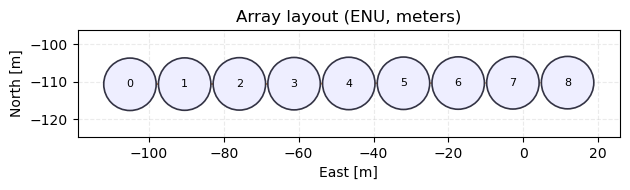

In [14]:
from pyuvdata import UVData

uv = UVData(); uv.read_uvh5(fname_for(233, 0))  # any of your files
geom = extract_array_geometry(uv, 
                              save_csv= None 
                            #   Path("/path/to/outdir")
                              )  # or None

# Print a quick peek
print(geom.ants_df.head())
print(geom.bls_df.head())

# Plot all antennas and (up to) the first 300 baselines
fig, ax = plot_array_geometry(geom, show_baselines=True, max_bls=300)

# …or only specific baselines:
# fig, ax = plot_array_geometry(geom, baselines_subset=[(0,1),(0,2),(1,2)], max_bls=None)
plt.show()


Read 350 antennas.


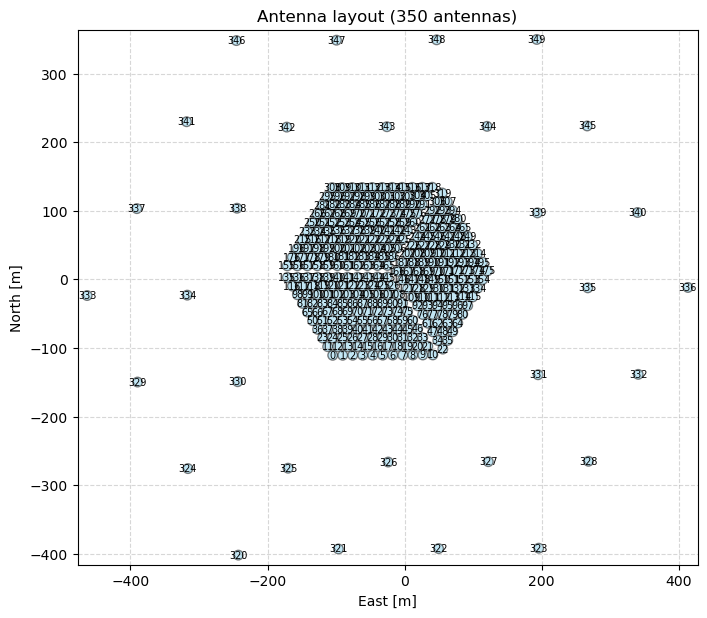

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class Antenna:
    number: int
    east: float
    north: float
    up: float

def read_enu_file(path: Path) -> list[Antenna]:
    """
    Read an ENU file with columns: Number  E  N  U
    Returns a list of Antenna(number, east, north, up).
    """
    data = []
    with open(path, "r") as f:
        for line in f:
            if line.strip().startswith("#") or not line.strip():
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            n, e, n_, u = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            data.append(Antenna(n, e, n_, u))
    return data


def plot_array(antennas, dish_radius=7.0, annotate=True):
    """
    Plot the array layout in the (E, N) plane with circles for each dish.
    dish_radius in meters.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    for ant in antennas:
        circ = plt.Circle((ant.east, ant.north), dish_radius, color='skyblue', alpha=0.5, ec='k')
        ax.add_patch(circ)
        if annotate:
            ax.text(ant.east, ant.north, str(ant.number), ha='center', va='center', fontsize=7)

    east = [a.east for a in antennas]
    north = [a.north for a in antennas]
    ax.set_aspect('equal')
    ax.set_xlabel("East [m]")
    ax.set_ylabel("North [m]")
    ax.set_title(f"Antenna layout ({len(antennas)} antennas)")
    ax.set_xlim(min(east) - 2*dish_radius, max(east) + 2*dish_radius)
    ax.set_ylim(min(north) - 2*dish_radius, max(north) + 2*dish_radius)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    path = Path("/lustre/aoc/projects/hera/rchandra/H6C_Validation_Stats/validation-sim/config_files/array_layouts/array_layout_hera_350.txt")   # <-- change this
    ants = read_enu_file(path)
    print(f"Read {len(ants)} antennas.")
    plot_array(ants, dish_radius=7.0)


Beam Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVBeam

# Optional for Healpix beams
try:
    import healpy as hp
    HAVE_HEALPY = True
except Exception:
    HAVE_HEALPY = False

def get_freqs_hz(beam: UVBeam) -> np.ndarray:
    """Return freq array as 1D Hz regardless of internal shape."""
    fa = beam.freq_array
    # print("fa ", fa) #[4.50e+07 4.60e+0 ... .49e+08 2.50e+08]
    if fa.ndim == 1:
        return fa
    elif fa.ndim == 2:
        return fa[0]
    else:
        return fa.reshape(-1)

def pick_freq_index(freqs_hz: np.ndarray, target_mhz=None) -> int:
    """Index of nearest frequency to target_mhz; default first."""
    if target_mhz is None:
        return 0
    fmhz = freqs_hz / 1e6
    return int(np.argmin(np.abs(fmhz - target_mhz)))

def show_metadata(beam: UVBeam):
    freqs = get_freqs_hz(beam)
    print("Beam metadata")
    print(f"telescope_name : {getattr(beam, 'telescope_name', 'N/A')}")
    print(f"beam_type : {beam.beam_type}")
    print(f"pixel_coordinate_system : {beam.pixel_coordinate_system}")
    print(f"Nfreqs : {beam.Nfreqs}")
    print(f"freq range (MHz) : {freqs.min()/1e6:.3f} → {freqs.max()/1e6:.3f}")
    print(f"Npols : {beam.Npols}")
    print(f"data_array shape : {beam.data_array.shape}")
    print(f"beam_unit : {getattr(beam, 'beam_unit', 'N/A')}")

def power_slice_at_freq(beam: UVBeam, fi: int) -> tuple[np.ndarray, str]:
    """
     make a 2D power-like slice at frequency index fi:
    - converts efield->power if needed
    - uses UVBeam.select(...) to slice frequency (avoids guessing axes)
    - averages pols if >1 to get an I-like map
    Returns (power2d, label).
    """
    b = beam.copy()
    # Convert efield to power if needed
    if b.beam_type == "efield":
        try:
            b.efield_to_power()
            label = "Power beam (≈Stokes I)"
        except Exception as e:
            # fallback later if needed
            label = f"Proxy power beam (|E|^2 sum; efield_to_power failed: {e})"

    # Select just this frequency channel (in-place keeps metadata consistent)
    b.select(freq_chans=[fi], inplace=True)

    dat = np.squeeze(b.data_array)  # remove singleton axes (freq now singleton)
    print("data_array shape after freq select:", dat.shape, dat)
    # If we still have efield (rare if conversion failed), proxy power = sum |E|^2 over efield comp.
    if b.beam_type == "efield":
        # dat might be shaped like (Nefield, ..., Ny, Nx) or similar. Sum over the smallest axis
        # likely corresponding to efield components (usually size 2).
        # Safer: sum over any axis whose length matches original beam.Nfeeds if present.
        # Simpler robust fallback:
        dat = np.array(dat, dtype=float)
        if dat.ndim >= 3:
            # sum over first axis as proxy for efield components
            dat = np.sum(np.abs(dat)**2, axis=0)
        else:
            dat = np.abs(dat)**2
        label = "Proxy power beam (|E|^2 sum)"
    if b.beam_type == "power":
        label = "Power beam (Stokes I)"

    # If we have multiple pols, average to get an I-like map
    if hasattr(b, "Npols") and b.Npols and b.Npols > 1:
        # find a pol axis by shape match
        pol_axis = next((ax for ax, s in enumerate(dat.shape) if s == b.Npols), None)
        if pol_axis is not None:
            dat = np.nanmean(dat, axis=pol_axis)

    # Now dat should be 2D over pixel axes; if 1D, try to reshape using Naxes2/Naxes1
    if dat.ndim == 1 and hasattr(b, "Naxes1") and hasattr(b, "Naxes2"):
        try:
            dat = dat.reshape(b.Naxes2, b.Naxes1)  # (za, az) for az_za grids
        except Exception:
            pass

    return dat, label


In [7]:
beam_path = "/home/herastore02-1/HERA_Validation_rchandra/NF_HERA_Vivaldi_efield_beam_extrap_0.fits"
# beam_path = "/home/herastore02-1/HERA_Validation_rchandra/airy_from_template_150MHz.fits"

beam = UVBeam()
beam.read_beamfits(beam_path)

show_metadata(beam)

freqs = get_freqs_hz(beam)
target_mhz = 75  # None means 0th freq (45 MHz)
fi = pick_freq_index(freqs, target_mhz)
freq_mhz = freqs[fi]/1e6
print(f"\nUsing frequency index {fi} ≈ {freq_mhz:.2f} MHz")

power2d, pow_label = power_slice_at_freq(beam, fi)
print(f"{pow_label}: peak={np.nanmax(power2d):.3e}, min={np.nanmin(power2d):.3e}")


Beam metadata
telescope_name          : HERA
beam_type               : efield
pixel_coordinate_system : az_za
Nfreqs                  : 206
freq range (MHz)        : 45.000 → 250.000
Npols                   : None
data_array shape        : (2, 2, 206, 181, 360)
beam_unit               : N/A

Using frequency index 30 ≈ 75.00 MHz
data_array shape after freq select: (4, 181, 360) [[[ 1.09230822e+03+0.j          1.09205492e+03+0.j
    1.09246686e+03+0.j         ...  1.09243232e+03+0.j
    1.09216682e+03+0.j          1.09256598e+03+0.j        ]
  [ 1.08570793e+03+0.j          1.08545128e+03+0.j
    1.08519534e+03+0.j         ...  1.08515896e+03+0.j
    1.08556212e+03+0.j          1.08530574e+03+0.j        ]
  [ 1.05950753e+03+0.j          1.05924523e+03+0.j
    1.05962176e+03+0.j         ...  1.05957006e+03+0.j
    1.05934580e+03+0.j          1.05975793e+03+0.j        ]
  ...
  [ 1.22780364e+01+0.j          1.22749969e+01+0.j
    1.22791084e+01+0.j         ...  1.22810464e+01+0.j
    1.2277

In [4]:
print(power2d.shape)
print(power2d[5,5])

power2d = np.asarray(power2d)

if np.iscomplexobj(power2d):
    # If the imaginary part is tiny compared to the real part, drop it;
    # otherwise fall back to magnitude.
    imax = np.nanmax(np.abs(power2d.imag))
    rmax = np.nanmax(np.abs(power2d.real)) + 1e-30
    if imax < 1e-10 * rmax:
        power2d = power2d.real
    else:
        power2d = np.abs(power2d)  # or np.abs(power2d)**2 depending on your convention


(181, 360)
(1859.9376653561508-1.7763568394002505e-15j)


Mollview Healpy Plot

In [8]:
# if beam.pixel_coordinate_system.lower() == "healpix":
#     if not HAVE_HEALPY:
#         print("healpy not installed; skip healpix plot.")
#     else:
#         plt.figure()
#         hp.mollview(power2d, title=f"{pow_label} @ {freq_mhz:.1f} MHz", unit="arb")
#         plt.show()


In [9]:
# # 1) Make sure inline plotting is on (run once per notebook)
# %matplotlib inline

# import numpy as np
# import healpy as hp
# import matplotlib.pyplot as plt

# # power2d might be 2D from earlier steps — flatten to 1D Healpix vec
# m = np.ravel(power2d).astype(float)

# # Optional: verify length matches Healpix NPpix = 12*nside^2
# try:
#     nside = beam.nside  # if UVBeam has it
# except AttributeError:
#     nside = hp.npix2nside(len(m))  # infer from length

# assert len(m) == hp.nside2npix(nside), f"Map length {len(m)} != 12*nside^2 for nside={nside}"

# # 2) Let healpy create/manage the figure; ask for a handle so we can force a draw
# fig = hp.mollview(m, title=f"{pow_label} @ {freq_mhz:.1f} MHz", unit="arb", return_fig=True)

# # 3) Force draw + show in Jupyter
# fig.canvas.draw()
# plt.show()


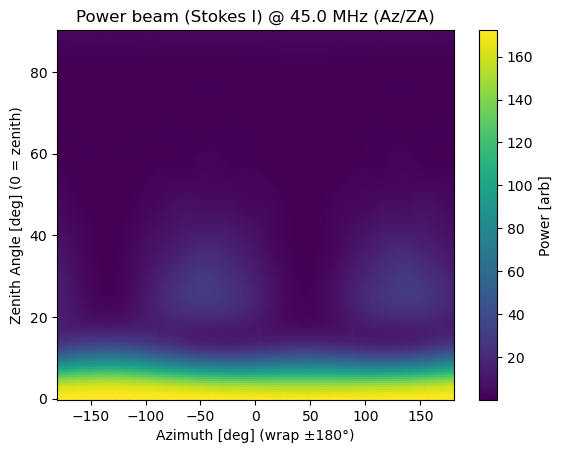

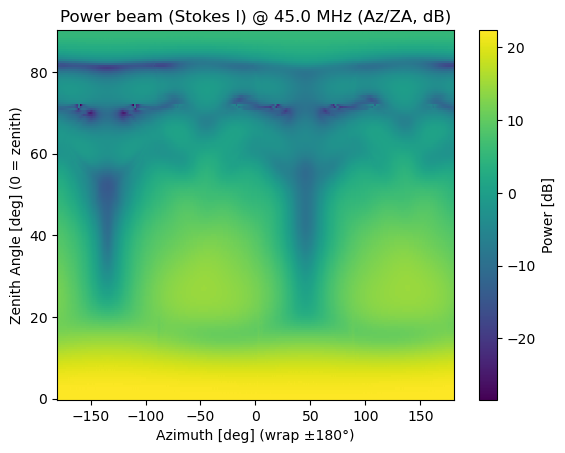

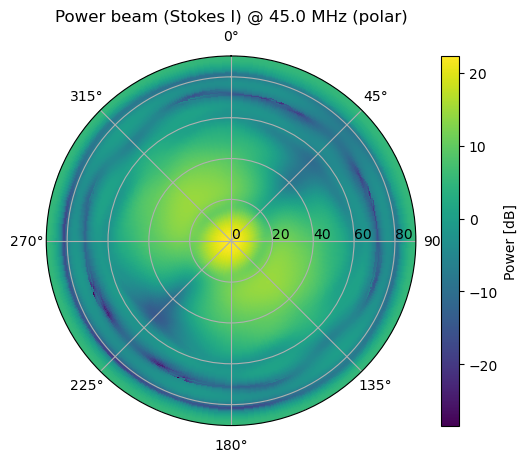

In [6]:
pcs = beam.pixel_coordinate_system.lower()

if pcs == "healpix":
    if not HAVE_HEALPY:
        print("healpy not installed; skipping Healpix plot.")
    else:
        hp.mollview(np.ravel(power2d), title=f"{pow_label} @ {freq_mhz:.1f} MHz", unit="arb")
        plt.show()

elif pcs.startswith("az_za"):
    # Try to get coordinate grids for nicer axes
    try:
        az = np.rad2deg(beam.az_array).reshape(beam.Naxes2, beam.Naxes1)
        za = np.rad2deg(beam.za_array).reshape(beam.Naxes2, beam.Naxes1)
    except Exception:
        # fallback grids
        n_za, n_az = power2d.shape
        az, za = np.meshgrid(np.linspace(-180, 180, n_az), np.linspace(0, 90, n_za))

    plt.figure()
    plt.pcolormesh(az, za, power2d, shading="auto")
    plt.colorbar(label="Power [arb]")
    plt.xlabel("Azimuth [deg] (wrap ±180°)")
    plt.ylabel("Zenith Angle [deg] (0 = zenith)")
    plt.title(f"{pow_label} @ {freq_mhz:.1f} MHz (Az/ZA)")
    plt.show()

    plt.figure()
    plt.pcolormesh(az, za, 10*np.log10(np.maximum(power2d, 1e-12)), shading="auto")
    plt.colorbar(label="Power [dB]")
    plt.xlabel("Azimuth [deg] (wrap ±180°)")
    plt.ylabel("Zenith Angle [deg] (0 = zenith)")
    plt.title(f"{pow_label} @ {freq_mhz:.1f} MHz (Az/ZA, dB)")
    plt.show()

    # Optional polar
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="polar")
    theta = np.deg2rad(az)
    r = za
    pcm = ax.pcolormesh(theta, r, 10*np.log10(np.maximum(power2d, 1e-12)), shading="auto")
    fig.colorbar(pcm, ax=ax, label="Power [dB]")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(90)
    ax.set_title(f"{pow_label} @ {freq_mhz:.1f} MHz (polar)")
    plt.show()
else:
    print(f"[info] Unhandled pixel system: {beam.pixel_coordinate_system}")


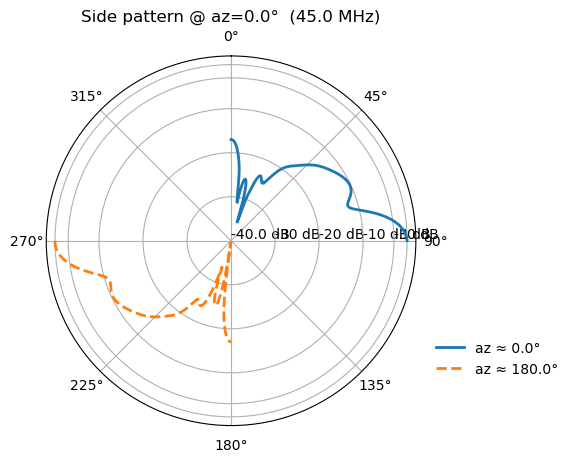

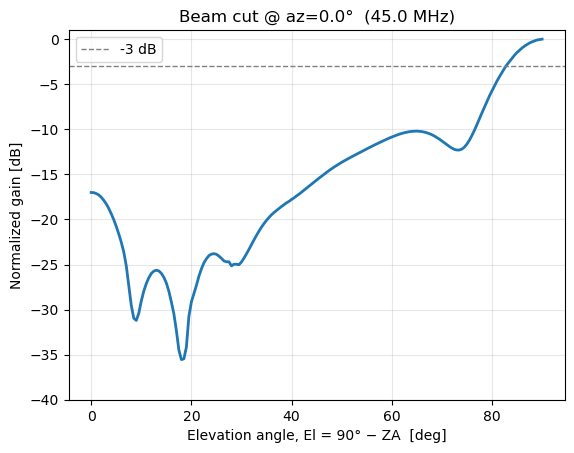

Note: could not find both -3 dB crossings (main lobe too flat/narrow or noisy).


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def _as_real_power(arr):
    arr = np.asarray(arr)
    if np.iscomplexobj(arr):
        # drop tiny numerical imaginary parts; otherwise use magnitude
        imax = np.nanmax(np.abs(arr.imag)) if arr.size else 0.0
        rmax = np.nanmax(np.abs(arr.real)) + 1e-30
        return arr.real if imax < 1e-10 * rmax else np.abs(arr)
    return arr

def _az_band_average(power2d, az_deg_grid, za_deg_grid, az_c_deg, halfwidth_deg=0.5):
    """Average a narrow azimuth band (±halfwidth_deg) to get a smooth slice vs ZA."""
    P = _as_real_power(power2d)
    az = np.mod(az_deg_grid, 360.0)         # wrap to [0,360)
    azc = np.mod(az_c_deg, 360.0)

    # circular distance in az
    d = np.minimum(np.abs(az - azc), 360.0 - np.abs(az - azc))
    cols = (d[0, :] <= halfwidth_deg)
    if not np.any(cols):
        j = int(np.argmin(d[0, :]))
        prof = P[:, j]
    else:
        prof = np.nanmean(P[:, cols], axis=1)

    za_line = za_deg_grid[:, 0]             # ZA in degrees along the rows
    return za_line, prof

def _interp_crossing(x, y, ylevel):
    """Find where y crosses ylevel on each side of the peak; return (xL, xR) (can be None)."""
    if len(x) < 3:
        return None, None
    i_pk = int(np.nanargmax(y))
    # left side
    xL = None
    for i in range(i_pk, 0, -1):
        if (y[i] - ylevel) * (y[i-1] - ylevel) <= 0:
            # linear interp between i-1 and i
            t = (ylevel - y[i]) / (y[i-1] - y[i] + 1e-30)
            xL = x[i] + t * (x[i-1] - x[i])
            break
    # right side
    xR = None
    for i in range(i_pk, len(x)-1):
        if (y[i] - ylevel) * (y[i+1] - ylevel) <= 0:
            t = (ylevel - y[i]) / (y[i+1] - y[i] + 1e-30)
            xR = x[i] + t * (x[i+1] - x[i])
            break
    return xL, xR

def plot_side_pattern_with_beamwidth(power2d, az_deg_grid, za_deg_grid,
                                     az_slice_deg=0.0, avg_halfwidth_deg=0.5,
                                     freq_mhz=None, db_floor=-40.0):
    """
    Make two plots for a chosen azimuth plane:
      (1) Polar side pattern (front & back) normalized to 0 dB at main lobe
      (2) Cartesian gain(dB) vs elevation angle with -3 dB beamwidth marked
    """
    # --- take two slices: front (az=φ) and back (φ+180)
    za_f, p_f = _az_band_average(power2d, az_deg_grid, za_deg_grid,
                                 az_slice_deg, halfwidth_deg=avg_halfwidth_deg)
    za_b, p_b = _az_band_average(power2d, az_deg_grid, za_deg_grid,
                                 az_slice_deg + 180.0, halfwidth_deg=avg_halfwidth_deg)

    # Normalize to main-lobe peak across both halves
    Pmax = np.nanmax([np.nanmax(p_f), np.nanmax(p_b), 1e-30])
    pf_lin = np.clip(p_f / Pmax, 1e-30, None)
    pb_lin = np.clip(p_b / Pmax, 1e-30, None)
    pf_db  = 10*np.log10(pf_lin)
    pb_db  = 10*np.log10(pb_lin)

    # --- (1) POLAR SIDE PATTERN ---
    # Use elevation El = 90° - ZA. Map back half by adding π to angle.
    el_f = 90.0 - za_f
    el_b = 90.0 - za_b
    th_f = np.deg2rad(el_f)           # [-π/2, +π/2] if ZA∈[0,180]
    th_b = np.deg2rad(el_b) + np.pi   # rotate 180° for back lobe

    # Use a dB-radius so outer ring is 0 dB, inner is db_floor
    # radius r = max(0, GdB - db_floor)
    r_f = np.clip(pf_db - db_floor, 0, None)
    r_b = np.clip(pb_db - db_floor, 0, None)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="polar")
    ax.plot(th_f, r_f, lw=2, label=f"az ≈ {az_slice_deg%360:.1f}°")
    ax.plot(th_b, r_b, lw=2, ls="--", label=f"az ≈ {(az_slice_deg+180)%360:.1f}°")
    ax.set_theta_zero_location("N")   # 0° at zenith (up)
    ax.set_theta_direction(-1)        # clockwise increase
    ax.set_rlabel_position(90)
    # Ticks in dB: map each tick d to radius = d - db_floor
    tick_db = [db_floor, -30, -20, -10, -3, 0]
    tick_r  = [max(0, d - db_floor) for d in tick_db]
    ax.set_rticks(tick_r)
    ax.set_yticklabels([f"{d} dB" for d in tick_db])
    ttl = f"Side pattern @ az={az_slice_deg%360:.1f}°"
    if freq_mhz is not None:
        ttl += f"  ({freq_mhz:.1f} MHz)"
    ax.set_title(ttl)
    ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.1), frameon=False)
    plt.show()

    # --- (2) CARTESIAN CUT + -3 dB BEAMWIDTH ---
    # Use the *front* half for beamwidth (standard main-lobe measure)
    # X-axis as elevation angle (−90° .. +90°), Y as gain in dB (0 dB max)
    x_el = el_f
    y_db = pf_db

    # Find -3 dB crossings around peak
    xL, xR = _interp_crossing(x_el, y_db, ylevel=-3.0)
    bw = None if (xL is None or xR is None) else (xR - xL)

    plt.figure()
    plt.plot(x_el, y_db, lw=2)
    plt.axhline(-3, color='gray', lw=1, ls='--', label='-3 dB')
    if bw is not None:
        plt.axvspan(min(xL, xR), max(xL, xR), color='C1', alpha=0.2,
                    label=f'Beamwidth ≈ {bw:.2f}°')
        # vertical markers
        plt.axvline(xL, color='C1', lw=1, ls=':')
        plt.axvline(xR, color='C1', lw=1, ls=':')
    plt.xlabel("Elevation angle, El = 90° − ZA  [deg]")
    plt.ylabel("Normalized gain [dB]")
    title = f"Beam cut @ az={az_slice_deg%360:.1f}°"
    if freq_mhz is not None:
        title += f"  ({freq_mhz:.1f} MHz)"
    plt.title(title)
    plt.ylim(db_floor, 1)   # show down to floor, up to a tad over 0 dB
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if bw is None:
        print("Note: could not find both -3 dB crossings (main lobe too flat/narrow or noisy).")
    else:
        print(f"-3 dB beamwidth ≈ {bw:.3f} degrees at az={az_slice_deg%360:.1f}°")


# az, za must be in DEGREES and shaped like power2d (Nza, Naz)
plot_side_pattern_with_beamwidth(
    power2d, az_deg_grid=az, za_deg_grid=za,
    az_slice_deg=0.0,        # choose your azimuth plane: 0, 90, 180, ...
    avg_halfwidth_deg=0.5,   # average ±0.5° around that az for smoother slice
    freq_mhz=freq_mhz,
    db_floor=-40.0           # depth of polar rings / y-axis floor
)


In [7]:
from pyuvdata import UVBeam
import numpy as np

beam = UVBeam()
beam.read_beamfits("/home/herastore02-1/HERA_Validation_rchandra/NF_HERA_Vivaldi_efield_beam_extrap_0.fits")
print("NaNs in beam:", np.isnan(beam.data_array).sum())
print("Infs in beam:", np.isinf(beam.data_array).sum())


NaNs in beam: 0
Infs in beam: 0


In [9]:
from pyuvdata import UVBeam
import numpy as np

beam = UVBeam()
beam.read_beamfits("/home/herastore02-1/HERA_Validation_rchandra/NF_HERA_Vivaldi_efield_beam_extrap_0.fits")

print("NaNs in beam data:", np.isnan(beam.data_array).sum())
print("Beam coord system:", beam.pixel_coordinate_system)
print("Beam nside:", beam.nside)


NaNs in beam data: 0
Beam coord system: az_za
Beam nside: None


In [16]:
from pyuvdata import UVBeam
import numpy as np

# ----------------------------------------------------
# Load Your Beam
# ----------------------------------------------------
beam_path = "/home/herastore02-1/HERA_Validation_rchandra/NF_HERA_Vivaldi_efield_beam_extrap_0.fits"

beam = UVBeam()
beam.read_beamfits(beam_path)

print("Loaded beam.")
print("pixel_coordinate_system:", beam.pixel_coordinate_system)
print("data_array shape:", beam.data_array.shape)

# ----------------------------------------------------
# Inspect beam grid extents (az, za coordinates)
# ----------------------------------------------------

# For az_za beams, beam.axis1_array = az, beam.axis2_array = za
az_grid = beam.axis1_array   # radians
za_grid = beam.axis2_array   # radians

print("\nBeam grid extents:")
print("az range:", az_grid.min(), "to", az_grid.max())
print("za range:", za_grid.min(), "to", za_grid.max())

# ----------------------------------------------------
# Create test direction arrays
# ----------------------------------------------------

# Good directions inside the beam grid
az_good  = np.array([0.0, np.pi/4, np.pi/2])           # within [0, 2π)
za_good  = np.array([0.0, np.pi/6, np.pi/4])           # within [0, π/2]

# Bad directions outside the grid
az_bad = np.array([0.0, 3*np.pi])                      # 3π outside az grid
za_bad = np.array([-0.1, np.pi])                       # below horizon, above zenith

# Ensure correct shape (Npoints,)
az_good = az_good.ravel()
za_good = za_good.ravel()
az_bad  = az_bad.ravel()
za_bad  = za_bad.ravel()

# Frequency: take one freq from beam (Hz)
freq = np.array([beam.freq_array[0]])  # shape (1,)

# ----------------------------------------------------
# Helper to run interpolation
# ----------------------------------------------------

def interp_and_report(label, az, za):
    print(f"\n--- Interpolating beam at {label} points ---")
    try:
        # Using PyUVData's native interpolation
        result = beam.interp(
            az_array=az,
            za_array=za,
            freq_array=freq,
            reuse_spline=True,
        )
        print(result)
        # result is dict: {pol: E-field or power array}
        for key, val in result.items():
            val = np.asarray(val)
            print(f"Pol {key}: shape {val.shape}, NaNs: {np.isnan(val).sum()}")
    except Exception as exc:
        print(f"Interpolation FAILED for {label}: {exc}")

# ----------------------------------------------------
# Run diagnostics
# ----------------------------------------------------

interp_and_report("GOOD (safe)", az_good, za_good)
interp_and_report("BAD (out-of-bounds)", az_bad, za_bad)


Loaded beam.
pixel_coordinate_system: az_za
data_array shape: (2, 2, 206, 181, 360)

Beam grid extents:
az range: 0.0 to 6.265732014659643
za range: 0.0 to 3.141592653589793

--- Interpolating beam at GOOD (safe) points ---
(array([[[[ 0.02242361-4.91791026e-02j,  2.47653155+2.46471651e+00j,
           6.8305278 -3.03143844e+00j]],

        [[ 8.18966097-1.65996853e+01j, -2.48845139-2.47683884e+00j,
          -0.0147088 +7.37686226e-03j]]],


       [[[ 8.18966097-1.65996853e+01j, -0.42243847-4.86368890e+00j,
           0.18790063-2.87909350e-01j]],

        [[-0.02242361+4.91791026e-02j, -0.41985687-4.84082650e+00j,
          -1.85539454-1.01525175e+00j]]]]), array([[[1., 1., 1.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [1., 1., 1.]]]))
Interpolation FAILED for GOOD (safe): 'tuple' object has no attribute 'items'

--- Interpolating beam at BAD (out-of-bounds) points ---
Interpolation FAILED for BAD (out-of-bounds): at least one interpolation location is outside of the UV

In [ ]:
if beam.pixel_coordinate_system.lower().startswith("az_za"):
    # cut at az ≈ 0°
    try:
        j0 = np.argmin(np.abs(az2d[0, :]))
        cut_za0 = p2d[:, j0]
        print("1D cut vs ZA at az≈0° (first 12):")
        print(np.array2string(cut_za0[:12], precision=3, suppress_small=True))
    except Exception:
        pass

    # cut at ZA ≈ 30°
    try:
        i30 = np.argmin(np.abs(za2d[:, 0] - 30.0))
        cut_az30 = p2d[i30, :]
        print("\n1D cut vs AZ at ZA≈30° (first 12):")
        print(np.array2string(cut_az30[:12], precision=3, suppress_small=True))
    except Exception:
        pass


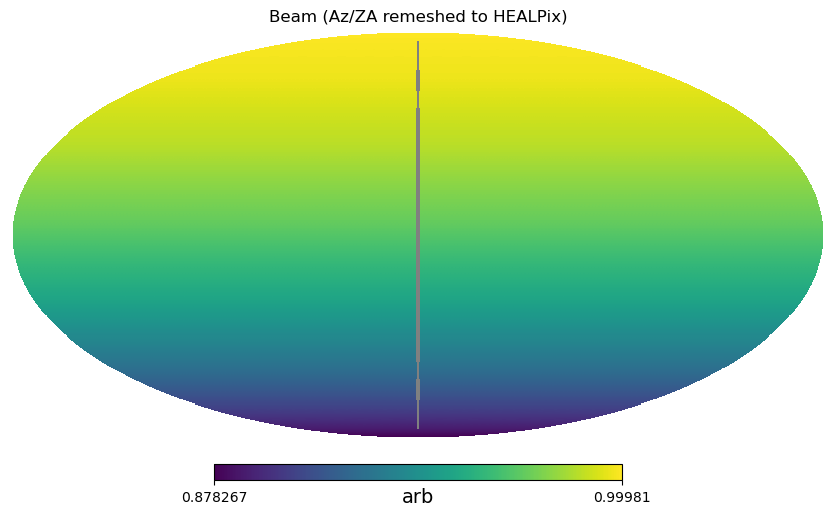

In [12]:
import numpy as np

# Optional deps
try:
    import healpy as hp
    HAVE_HEALPY = True
except Exception:
    HAVE_HEALPY = False

try:
    from scipy.interpolate import RegularGridInterpolator
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

def azza_to_healpix(power2d, az2d_rad, za2d_rad, nside=256, method="linear"):
    """
    Remesh an Az/ZA gridded beam (power2d) to a HEALPix full-sky map.

    Parameters
    ----------
    power2d : (Nza, Naz) array
        Beam values on a regular grid over ZA (rows) and AZ (cols).
    az2d_rad, za2d_rad : (Nza, Naz) arrays
        Azimuth and zenith-angle grids in *radians*. AZ can be in [-pi,pi] or [0,2pi).
    nside : int
        HEALPix NSIDE for the output map.
    method : {"linear","nearest"}
        Interpolation method (ignored if SciPy not installed; then nearest is used).

    Returns
    -------
    hmap : (12*nside**2,) array
        HEALPix map. Pixels below horizon (theta > max ZA grid) are set to hp.UNSEEN.
    """
    if not HAVE_HEALPY:
        raise RuntimeError("healpy not available")

    # Coerce to real, handle tiny imaginary residuals
    power = np.asarray(power2d)
    if np.iscomplexobj(power):
        if np.nanmax(np.abs(power.imag)) < 1e-10 * (np.nanmax(np.abs(power.real)) + 1e-30):
            power = power.real
        else:
            power = np.abs(power)

    # Build monotonic axes: ZA is usually already 0..Zmax; AZ may wrap at ±pi
    za_grid = np.asarray(za2d_rad)
    az_grid = np.asarray(az2d_rad)

    # Map AZ to [0, 2π) to remove the wrap discontinuity, then sort by AZ
    az_wrapped = np.mod(az_grid, 2*np.pi)

    # Deduce 1D axes assuming rectilinear grid
    # Take first column for ZA axis, first row for AZ axis (after wrap)
    za_axis = np.unique(za_grid[:, 0])
    az_axis = np.unique(az_wrapped[0, :])

    # If the last az bin duplicates the first (≈ 0 and 2π), drop one
    if np.isclose((az_axis[-1] - az_axis[0]) - 2*np.pi, 0, atol=1e-6):
        az_axis = az_axis[:-1]
        power = power[:, :power.shape[1]-1]

    # Ensure ascending
    i_sort_za = np.argsort(za_axis)
    i_sort_az = np.argsort(az_axis)
    za_axis = za_axis[i_sort_za]
    az_axis = az_axis[i_sort_az]
    power = power[i_sort_za, :][:, i_sort_az]

    # Prepare HEALPix query points: theta=ZA, phi=AZ
    npix = hp.nside2npix(nside)
    theta_hp, phi_hp = hp.pix2ang(nside, np.arange(npix))  # theta in [0,π], phi in [0,2π)

    # Interpolate from (ZA, AZ) -> values
    if HAVE_SCIPY and method == "linear":
        interp = RegularGridInterpolator(
            (za_axis, az_axis), power, bounds_error=False, fill_value=np.nan
        )
        pts = np.column_stack([theta_hp, phi_hp])  # (theta=ZA, phi=AZ)
        vals = interp(pts)
    else:
        # Nearest-neighbor fallback
        # Map (theta,phi) to nearest indices on (za_axis, az_axis)
        iz = np.searchsorted(za_axis, theta_hp, side="left")
        iz = np.clip(iz, 0, len(za_axis)-1)
        ia = np.searchsorted(az_axis, phi_hp, side="left")
        ia = np.clip(ia, 0, len(az_axis)-1)
        vals = power[iz, ia]

    # Mask below horizon: if grid only covers za up to Zmax < π
    zmax = np.nanmax(za_axis)
    unseen_mask = theta_hp > zmax + 1e-6
    if unseen_mask.any():
        vals = np.asarray(vals)
        # Use UNSEEN for masked pixels so healpy skips them
        vals[unseen_mask] = hp.UNSEEN

    return vals

# ---- Example usage in your notebook ----
# Assuming you already have:
#   power2d  shape (Nza, Naz)  (real or complex)
#   az2d     shape (Nza, Naz)  in radians
#   za2d     shape (Nza, Naz)  in radians

hmap = azza_to_healpix(power2d, az2d_rad=az, za2d_rad=za, nside=256, method="linear")
hp.mollview(hmap, title="Beam (Az/ZA remeshed to HEALPix)", unit="arb", norm=None)
import matplotlib.pyplot as plt; plt.show()


In [7]:
import numpy as np
from scipy.special import j1
from pyuvdata import UVBeam

def airy_power(theta_rad, freq_hz, diameter_m):
    """
    Airy-disk power pattern for a circular aperture:
    P(theta) = |2*J1(x)/x|^2,   x = pi*D*sin(theta)/lambda
    """
    lam = 3e8 / float(freq_hz)
    x = np.pi * float(diameter_m) * np.sin(theta_rad) / lam
    out = np.ones_like(x, dtype=float)
    nz = (x != 0)
    out[nz] = (2.0 * j1(x[nz]) / x[nz])**2
    return out

def make_airy_uvbeam_azza(
    freqs_hz,
    diameter_m=14.0,
    nza=181,          # ZA samples
    naz=360,          # AZ samples
    za_max_deg=90.0,
    telescope_name="HERA",
    filename="airy_beam_azza.fits",
):
    freqs_hz = np.atleast_1d(np.array(freqs_hz, dtype=float))
    nfreqs = freqs_hz.size

    # 1D ZA and AZ axes (degrees)
    za_deg = np.linspace(0.0, za_max_deg, nza)             # 0..90
    az_deg = np.linspace(0.0, 360.0, naz, endpoint=False)  # 0..360
    # 2D grid for computing the pattern
    za2d_deg, az2d_deg = np.meshgrid(za_deg, az_deg, indexing="ij")  # (Nza, Naz)
    theta = np.deg2rad(za2d_deg)  # theta = ZA in radians

    # ---- data_array: shape (Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1)
    Naxes_vec = 1   # one Stokes-like scalar: I
    Nspws = 1

    data = np.empty((Naxes_vec, Nspws, nfreqs, nza, naz), dtype=float)
    for fi, f in enumerate(freqs_hz):
        prof = airy_power(theta, f, diameter_m)  # (Nza, Naz)
        prof /= np.nanmax(prof)                 # peak normalize to 1
        data[0, 0, fi, :, :] = prof

    # ---- Fill UVBeam ----
    beam = UVBeam()
    beam.beam_type = "power"
    beam.pixel_coordinate_system = "az_za"
    beam.antenna_type = "simple"       # required
    beam.telescope_name = telescope_name

    # feeds (required)
    beam.Nfeeds = 1
    beam.feed_name = "AIRY"   # or "simple", "hera_dish", etc.

    # Axes sizes
    beam.Naxes1 = naz                  # azimuth axis length
    beam.Naxes2 = nza                  # zenith-angle axis length
    beam.Naxes_vec = Naxes_vec

    # Axis coordinate arrays MUST be 1-D, lengths (Naxes1,), (Naxes2,)
    beam.axis1_array = np.deg2rad(az_deg)   # shape (naz,)
    beam.axis2_array = np.deg2rad(za_deg)   # shape (nza,)

    # Frequencies & spectral windows: freq_array shape (Nspws, Nfreqs)
    beam.Nspws = Nspws
    beam.spw_array = np.array([0], dtype=int)
    beam.Nfreqs = nfreqs
    beam.freq_array = freqs_hz[np.newaxis, :].astype(float)     # (1, Nfreqs)
    beam.bandpass_array = np.ones(nfreqs, dtype=float)         # (1,)

    # Polarization: Stokes I
    beam.Npols = 1
    beam.polarization_array = np.array([1], dtype=int)          # AIPS: +1 = Stokes I

    # Data & units
    beam.data_array = data
    beam.beam_unit = "dimensionless"
    beam.data_normalization = "peak"
    beam.history = "Analytical Airy power beam generated in notebook."
    beam.reference = "Airy model"
    beam.extra_keywords = {"model": "Airy", "diameter_m": float(diameter_m)}

    # Sanity check & write
    beam.check()
    beam.write_beamfits(filename, clobber=True)
    print(f"Wrote Airy power beam to {filename}")
    return beam, filename


In [8]:
beam, outfile = make_airy_uvbeam_azza(
    freqs_hz=[150e6],
    diameter_m=14.0,
    nza=181,
    naz=360,
    za_max_deg=90.0,
    filename="/home/herastore02-1/HERA_Validation_rchandra/airy_beam_150MHz_azza.fits",
)


ValueError: Required UVParameter _feed_version has not been set.

In [1]:
import numpy as np
from scipy.special import j1
from pyuvdata import UVBeam

def airy_power(theta_rad, freq_hz, diameter_m):
    """
    Airy-disk power pattern for a circular aperture:
    P(theta) = |2*J1(x)/x|^2,   x = pi*D*sin(theta)/lambda
    """
    lam = 3e8 / float(freq_hz)
    x = np.pi * float(diameter_m) * np.sin(theta_rad) / lam
    out = np.ones_like(x, dtype=float)
    nz = (x != 0)
    out[nz] = (2.0 * j1(x[nz]) / x[nz])**2
    return out

def make_airy_from_template(
    template_beam_fits,
    outfile,
    diameter_m=14.0,
):
    """
    Read a HERA efield beam, convert to power, and overwrite the power pattern
    with an analytic Airy beam on the same AZ/ZA grid and frequencies.
    """
    beam = UVBeam()
    beam.read_beamfits(template_beam_fits)

    # Inspect shapes
    print("Pre e to pow")
    print("beam_type         :", beam.beam_type)
    print("pixel coords      :", beam.pixel_coordinate_system)
    print("data_array.shape  :", beam.data_array.shape)
    print("Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1:",
          beam.Naxes_vec, 
        #   beam.Nspws, 
          beam.Nfreqs, 
          beam.Naxes2, 
          beam.Naxes1)
    
    # Convert efield -> power, keeping all meta consistent
    if beam.beam_type == "efield":
        beam.efield_to_power()

    # Inspect shapes
    print("beam_type         :", beam.beam_type)
    print("pixel coords      :", beam.pixel_coordinate_system)
    print("data_array.shape  :", beam.data_array.shape)
    print("Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1:",
          beam.Naxes_vec, 
        #   beam.Nspws, 
          beam.Nfreqs, 
          beam.Naxes2, 
          beam.Naxes1)


    # Assume power beam data_array shape:
    #   (Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1)
    Nvec, Nspw, Nfreq, Nza, Naz = beam.data_array.shape

    # Get 1D axes (in radians) from the beam
    # axis1 = az, axis2 = za for az_za beams
    az_1d = beam.axis1_array         # length Naz
    za_1d = beam.axis2_array         # length Nza

    # Build 2D ZA/AZ grid for computing Airy pattern
    za2d, az2d = np.meshgrid(za_1d, az_1d, indexing="ij")  # (Nza, Naz)
    theta = za2d  # ZA is our polar angle

    # Overwrite data_array with Airy pattern at each frequency
    for fi in range(Nfreq):
        f = beam.freq_array[fi]   # freq_array is (Nspws, Nfreqs)
        airy2d = airy_power(theta, f, diameter_m)
        airy2d /= np.nanmax(airy2d)  # normalize peak to 1

        # Fill all vector/spw axes with this pattern
        for vi in range(Nvec):
            for si in range(Nspw):
                beam.data_array[vi, si, fi, :, :] = airy2d

    # Update metadata to note the change
    beam.history += " | Replaced power pattern with analytic Airy disk model."
    if hasattr(beam, "extra_keywords") and isinstance(beam.extra_keywords, dict):
        beam.extra_keywords["airy_model_diameter_m"] = float(diameter_m)

    # Sanity check & write
    beam.check()
    beam.write_beamfits(outfile, clobber=True)
    print(f"Wrote analytic Airy beam to {outfile}")
    return beam

# Example usage:
template = "/home/herastore02-1/HERA_Validation_rchandra/NF_HERA_Vivaldi_efield_beam_extrap_0.fits"
outfile  = "/home/herastore02-1/HERA_Validation_rchandra/airy_from_template_150MHz.fits"

airy_beam = make_airy_from_template(template, outfile, diameter_m=14.0)


Pre e to pow
beam_type         : efield
pixel coords      : az_za
data_array.shape  : (2, 2, 206, 181, 360)
Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1: 2 206 181 360
beam_type         : power
pixel coords      : az_za
data_array.shape  : (1, 4, 206, 181, 360)
Naxes_vec, Nspws, Nfreqs, Naxes2, Naxes1: 1 206 181 360


key airy_model_diameter_m in extra_keywords is longer than 8 characters. It will be truncated to 8 as required by the uvfits file format.


Wrote analytic Airy beam to /home/herastore02-1/HERA_Validation_rchandra/airy_from_template_150MHz.fits


In [3]:
import os, psutil 
def show_ram():
    proc = psutil.Process(os.getpid())
    rss = proc.memory_info().rss
    print(f"Notebook RAM usage: {rss/1e9:.2f} GB")

show_ram()


Notebook RAM usage: 1.01 GB
